In [1]:
import pandas as pd
import numpy as np
import networkx as nx
from itertools import combinations, product
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import os

from tqdm import tqdm
# from sdv.metadata import SingleTableMetadata
from numpy.core import multiarray
from sklearn.metrics import r2_score
from scipy.interpolate import CubicSpline, PchipInterpolator, Akima1DInterpolator
from scipy.stats import wasserstein_distance

import torch
import torch.nn as nn
import torch.optim as optim
from scipy.optimize import minimize
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.cluster import KMeans

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.api import ExponentialSmoothing


device = torch.device('cpu')

# plt.style.use('ggplot')
plt.style.use('default')

import matplotlib as mpl
#set params for the article
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 14
mpl.rcParams['axes.labelsize'] = 18

#set params for the notebook
# mpl.rcParams['xtick.labelsize'] = 12
# mpl.rcParams['ytick.labelsize'] = 12
# mpl.rcParams['legend.fontsize'] = 10
# mpl.rcParams['axes.labelsize'] = 14


# import category_encoders as ce

In [2]:
data = pd.read_csv('train_data.csv')

In [3]:
data = data.drop(['Этаж', 'Район', 'id', 'date', 'rooms', 'Цена', 'nprice'], axis=1)
data = data.drop(['metroprox', 'rwprox', 'medprox', 'kidprox', 'industrprox', 'Этажность объекта подземная', 'Этажность объекта наземная'], axis=1)
data['day'] = pd.to_datetime(data['day'])
data['month'] = data['day'].dt.month
data['year'] = data['day'].dt.year
data['day'] = data['day'].dt.day

data = data.drop(['day', 'month', 'year'], axis=1)
data = pd.concat([data['Квартиры среднего качества (типовые)'], data.drop('Квартиры среднего качества (типовые)', axis=1)], axis=1)

In [4]:
data = data.dropna()

In [5]:
data.shape

(253232, 17)

In [6]:
data.head()

,Квартиры среднего качества (типовые),Площадь квартиры,количество этажей всего,высота объекта,Количество квартир,Общая площадь объекта,Площадь жилых помещений объекта,lon,lat,floor,schoolprox,cemetprox,daysin,daycos,liveratio,highratio,pricemetr
0,1.648815,19.8,26.0,76.71,1056.0,76762.2,52066.5,37.348298,55.801606,2.0,0.001643,0.025956,-0.936881,-0.349647,0.678283,3.068400,0.295860
1,1.648815,50.8,26.0,76.71,1056.0,76762.2,52066.5,37.348298,55.801606,25.0,0.001643,0.025956,-0.972118,-0.234491,0.678283,3.068400,0.217977
2,1.644254,43.2,18.0,54.55,609.0,48074.8,34516.4,37.319359,55.638227,5.0,0.005334,0.044600,0.247022,-0.969010,0.717973,4.196154,0.214741
3,1.644254,39.7,18.0,54.55,609.0,48074.8,34516.4,37.319359,55.638227,10.0,0.005334,0.044600,0.213521,-0.976938,0.717973,4.196154,0.223181
4,1.644254,83.2,18.0,54.55,609.0,48074.8,34516.4,37.319359,55.638227,8.0,0.005334,0.044600,0.213521,-0.976938,0.717973,4.196154,0.182830


In [7]:
data = pd.concat([data.drop('pricemetr', axis=1), data['pricemetr']], axis=1)

In [8]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from deap import base, creator, tools, algorithms
import random

In [9]:
def train(X: pd.DataFrame, y: pd.Series, model):
    mape_arr = []
    r2_arr = []
    
    for _ in range(5):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
        
        model.fit(X_train, y_train)
        prediction = model.predict(X_test)
        
        mape_arr.append(mean_absolute_percentage_error(y_test.values, prediction))
        r2_arr.append(r2_score(y_test.values, prediction))
        
    
    return {'mape_mean': round(np.mean(mape_arr), 3), 'mape_std': round(np.std(mape_arr), 4),\
            'r2_mean': round(np.mean(r2_arr), 3), 'r2_std': round(np.std(r2_arr), 4)}

In [149]:
X_ex, y_ex = data.drop('pricemetr', axis=1), data['pricemetr']

# xgb = XGBRegressor()

# train(X, y, xgb)

In [11]:
# model_list = zip([XGBRegressor(), RandomForestRegressor(), LinearRegression(), KNeighborsRegressor()], ['XGB', 'RF', 'LR', 'KNN'])

# for model, name in model_list:
#     print(name, train(X, y, model))

In [12]:
# np.random.seed(55551)

# def create_synth_dataset(n_samples, noise_std=0.1):
#     X = np.random.rand(n_samples, 2)
    
#     main_coef = np.array([2.0, 3.0])
#     special_coef = np.array([2.0, -8.0])
    
#     special_region1 = (X[:, 0] > 0.1) & (X[:, 0] < 0.3) & (X[:, 1] > 0.6) & (X[:, 1] < 0.8)
#     special_region2 = (X[:, 0] > 0.6) & (X[:, 0] < 0.8) & (X[:, 1] > 0.3) & (X[:, 1] < 0.5)
#     special_regions = special_region1 | special_region2
    
#     y = X.dot(main_coef) + 7 + np.random.randn(n_samples) * noise_std
#     y[special_regions] = X[special_regions].dot(special_coef) + X[special_regions][:, 0]**2 - 4 + np.random.randn(sum(special_regions)) * noise_std

#     X = pd.DataFrame(X)
#     y = pd.DataFrame(y)

#     return X, y


# np.random.seed(55551)

# def create_synth_dataset(n_samples, noise_std=0.1):
#     X = np.random.rand(n_samples, 2)
    
#     main_coef = np.array([2.0, 3.0])
#     special_coef = np.array([2.0, -8.0])
    
#     special_region1 = (X[:, 0] > 0.1) & (X[:, 0] < 0.3) & (X[:, 1] > 0.5) & (X[:, 1] < 0.8)
#     special_region2 = (X[:, 0] > 0.5) & (X[:, 0] < 0.8) & (X[:, 1] > 0.3) & (X[:, 1] < 0.5)
#     special_regions = special_region1 | special_region2
    
#     y = X.dot(main_coef) + 7 + np.random.randn(n_samples) * noise_std
#     y[special_regions] = X[special_regions].dot(special_coef) + X[special_regions][:, 0]**2 - 4 + np.random.randn(sum(special_regions)) * noise_std

#     X = pd.DataFrame(X)
#     y = pd.DataFrame(y)

#     return X, y


# np.random.seed(55551)

# def create_synth_dataset(n_samples, noise_std=0.1):
#     X = np.random.rand(n_samples, 2)
    
#     main_coef = np.array([2.0, 3.0])
#     special_coef = np.array([2.0, -8.0])
    
#     special_region1 = (X[:, 0] > 0.1) & (X[:, 0] < 0.3) & (X[:, 1] > 0.2) & (X[:, 1] < 0.9)
#     special_region2 = (X[:, 0] > 0.3) & (X[:, 0] < 0.8) & (X[:, 1] > 0.3) & (X[:, 1] < 0.5)
#     special_regions = special_region1 | special_region2
    
#     y = X.dot(main_coef) + 7 + np.random.randn(n_samples) * noise_std
#     y[special_regions] = X[special_regions].dot(special_coef) + X[special_regions][:, 0]**2 - 4 + np.random.randn(sum(special_regions)) * noise_std

#     X = pd.DataFrame(X)
#     y = pd.DataFrame(y)

#     return X, y

In [13]:
# X_ex, y_ex = create_synth_dataset(1000)

In [14]:
# plt.figure(figsize=(10, 8))

# sc = plt.scatter(X_ex.iloc[:, 0], X_ex.iloc[:, 1], c=y_ex, cmap='seismic_r', alpha=0.7, edgecolors='none', s=50)
# plt.colorbar(sc, label='Target')
# plt.xlabel('Feature 1')
# plt.ylabel('Feature 2')

# plt.xlim(0, 1)
# plt.ylim(0, 1)
# plt.tight_layout(pad=0.5)
# # plt.savefig('images/synthetic_dataset.pdf', dpi=300)
# plt.show()

In [15]:
# np.random.seed(55555)

# X_ex1 = np.concatenate([np.random.uniform(0.0, 0.199, (100)), np.random.uniform(0.301, 0.599, (360)), np.random.uniform(0.701, 1.0, (340))]).reshape(-1, 1)
# np.random.shuffle(X_ex1)

# X_ex2 = np.concatenate([np.random.uniform(0.0, 0.999, (360)), np.random.uniform(0.301, 0.799, (340)), np.random.uniform(0.901, 1.0, (100))]).reshape(-1, 1)
# np.random.shuffle(X_ex2)


# X_ex = np.concatenate([X_ex1, X_ex2], axis=1)

# X_ex = np.concatenate([X_ex, np.concatenate([np.random.uniform(0.2, 0.3, (30, 1)), np.random.uniform(0.0, 0.799, (30, 1))], axis=1)])
# X_ex = np.concatenate([X_ex, np.concatenate([np.random.uniform(0.2, 0.3, (30, 1)), np.random.uniform(0.901, 1.0, (30, 1))], axis=1)])
# X_ex = np.concatenate([X_ex, np.concatenate([np.random.uniform(0.6, 0.7, (30, 1)), np.random.uniform(0.0, 0.999, (30, 1))], axis=1)])
# X_ex = np.concatenate([X_ex, np.concatenate([np.random.uniform(0.6, 0.7, (30, 1)), np.random.uniform(0.301, 1.0, (30, 1))], axis=1)])

# y_ex = 2 * X_ex[:, 0] + 3 * X_ex[:, 1] + 4 + np.random.normal(0, 0.1, (1000 - 80))
# # y_ex[np.random.randint(0, 1000, 10)] = y_ex[np.random.randint(0, 1000, 10)] + np.random.normal(0, 1, (10))
# # y_ex[np.where((X_ex[:, 0] < 0.2) & (X_ex[:, 0] > 0.1))[0]] = y_ex[np.where((X_ex[:, 0] < 0.2) & (X_ex[:, 0] > 0.1))[0]] + np.random.normal(0, 2)


# X_ex_b = np.concatenate([np.random.uniform(0.2, 0.3, (30, 1)), np.random.uniform(0.8, 0.9, (30, 1))], axis=1)
# y_ex_b = 2 * X_ex_b[:, 0] + 8 * X_ex_b[:, 1] - 32
# X_ex = np.concatenate([X_ex_b, X_ex])
# y_ex = np.concatenate([y_ex_b, y_ex])

# X_ex_b = np.concatenate([np.random.uniform(0.6, 0.7, (50, 1)), np.random.uniform(0.1, 0.3, (50, 1))], axis=1)
# y_ex_b = 2 * X_ex_b[:, 0] - 3 * X_ex_b[:, 1] + 1
# X_ex = np.concatenate([X_ex_b, X_ex])
# y_ex = np.concatenate([y_ex_b, y_ex])


# X_ex = pd.DataFrame(X_ex)
# y_ex = pd.DataFrame(y_ex)

In [16]:
# plt.scatter(X_ex.iloc[:, 0], X_ex.iloc[:, 1])
# plt.show()

In [17]:
# num_columns = X_ex.select_dtypes(include=[np.number]).columns.tolist()
# cat_columns = np.setdiff1d(X_ex.columns, num_columns)
num_columns = np.setdiff1d(X_ex.columns, ['Квартиры среднего качества (типовые)'])
cat_columns = ['Квартиры среднего качества (типовые)']

length_cat_ordinal = len(cat_columns)
# length_cat_onehot = []
# # length_num = len(X.iloc[0])
length_num = len(num_columns)

length_dict = {'length_cat_ordinal': length_cat_ordinal, 'length_cat_onehot': [], 'length_num': length_num}

In [18]:
# length_dict = {'length_cat_ordinal': 0, 'length_cat_onehot': [], 'length_num': 2}

## Baseline

In [295]:
def split_and_transform(X: pd.DataFrame, y: pd.DataFrame):
    scalers = {'scaler_X': MinMaxScaler(), 'scaler_y': MinMaxScaler(), 'ord_encoder': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)}
    
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    X_train, X_test, y_train, y_test = X_train.reset_index(drop=True), X_test.reset_index(drop=True), y_train.reset_index(drop=True), y_test.reset_index(drop=True)
    
    if length_dict['length_cat_ordinal'] == 0:
        X_train = pd.DataFrame(scalers['scaler_X'].fit_transform(X_train))
        X_test = pd.DataFrame(scalers['scaler_X'].transform(X_test))
        y_train = pd.DataFrame(scalers['scaler_y'].fit_transform(y_train.values.reshape(-1, 1)))
        y_test = pd.DataFrame(scalers['scaler_y'].transform(y_test.values.reshape(-1, 1)))
        
        
    elif length_dict['length_cat_ordinal'] != 0:
        X_train[cat_columns] = pd.DataFrame(scalers['ord_encoder'].fit_transform(X_train[cat_columns]))
        X_test[cat_columns] = pd.DataFrame(scalers['ord_encoder'].transform(X_test[cat_columns]))
        
        X_train[num_columns] = pd.DataFrame(scalers['scaler_X'].fit_transform(X_train[num_columns]))
        X_test[num_columns] = pd.DataFrame(scalers['scaler_X'].transform(X_test[num_columns]))
        
        y_train = pd.DataFrame(scalers['scaler_y'].fit_transform(y_train.values.reshape(-1, 1)))
        y_test = pd.DataFrame(scalers['scaler_y'].transform(y_test.values.reshape(-1, 1)))
        
    return X_train, X_test, y_train, y_test, scalers


def train_model(model_type, X_train, y_train):
    model = model_type
    model.fit(X_train.values, y_train.values)
    
    return model


def evaluate_model(model_type, X, y):
    metrics = {'mse': [], 'r2': [], 'mape': []}
    
    for _ in range(31):
        X_train, X_test, y_train, y_test, scalers = split_and_transform(X, y)
        model = train_model(model_type, X_train, y_train)
        
        prediction = model.predict(X_test)
    
        metrics['mse'].append(mean_squared_error(y_test.values, prediction))
        metrics['r2'].append(r2_score(y_test.values, prediction))
        metrics['mape'].append(mean_absolute_percentage_error(y_test.values, prediction))
    
    metrics_df = pd.DataFrame([[np.mean(metrics['mse']), np.std(metrics['mse'])],
                               [np.mean(metrics['r2']), np.std(metrics['r2'])],
                               [np.mean(metrics['mape']), np.std(metrics['mape'])]], columns=['MEAN', 'STD'], index=['mse', 'r2', 'mape'])
        
    return metrics_df.round(3)

In [296]:
X_train, X_test, y_train, y_test, scalers = split_and_transform(X_ex, y_ex)

In [297]:
baseline_model = train_model(LinearRegression(), X_train, y_train)
new_model = train_model(XGBRegressor(n_estimators=200, max_depth=3), X_train, y_train)

In [298]:
# print(new_model.get_booster().num_boosted_rounds())

In [299]:
baseline_prediction = baseline_model.predict(X_test).flatten()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [300]:
evaluate_model(LinearRegression(), X_ex, y_ex)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarnin

,MEAN,STD
mse,1.000000e-03,0.000000e+00
r2,3.330000e-01,7.000000e-03
mape,9.439291e+08,2.884846e+09


In [301]:
evaluate_model(XGBRegressor(), X_ex, y_ex)

,MEAN,STD
mse,0.000000e+00,0.000000e+00
r2,8.620000e-01,1.100000e-02
mape,2.823107e+08,1.546279e+09


In [302]:
# scaler_X_train = MinMaxScaler()
# scaler_y_train = MinMaxScaler()
# data = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)

# X_train, X_test, y_train, y_test = train_test_split(data.drop('pricemetr', axis=1), data['pricemetr'], test_size=0.2, random_state=55555)
# X_train, X_test, y_train, y_test = train_test_split(X_ex, y_ex, test_size=0.2, random_state=55555)

# X_train = pd.DataFrame(scaler_X_train.fit_transform(X_train))
# X_test = pd.DataFrame(scaler_X_train.transform(X_test))
# y_train = pd.DataFrame(scaler_y_train.fit_transform(y_train.values.reshape(-1, 1)))
# y_test = pd.DataFrame(scaler_y_train.transform(y_test.values.reshape(-1, 1)))


# xgb = XGBRegressor()
# xgb = LinearRegression()

# xgb.fit(X_train, y_train)

In [303]:
# new_reg_model = XGBRegressor()
# new_reg_model.fit(X_train, y_train)

In [304]:
# xgb_pred = xgb.predict(X_test)

In [305]:
# plt.scatter(y_test.values, xgb_pred)
# plt.plot(np.linspace(0, 0.6, 10), np.linspace(0, 0.6, 10), color='black')
# plt.show()

## Select bad examples

In [306]:
def select_bad_examples(X: pd.DataFrame, y: pd.DataFrame, predictions: np.array, thrs: float = 0.05):
    idx_bad = np.where(np.abs(y.values.flatten() - predictions.flatten()) >= thrs)[0]
    bad_y = y.iloc[idx_bad]
    bad_X = X.iloc[idx_bad]
    
    return bad_X, bad_y

In [307]:
bad_X, bad_y = select_bad_examples(X_test, y_test, baseline_prediction, 0.08)

In [308]:
(len(bad_X) / len(X_test)) * 100

0.8588860149663357

In [309]:
X_test

,Квартиры среднего качества (типовые),Площадь квартиры,количество этажей всего,высота объекта,Количество квартир,Общая площадь объекта,Площадь жилых помещений объекта,lon,lat,floor,schoolprox,cemetprox,daysin,daycos,liveratio,highratio
0,6.0,0.307189,0.366667,0.255260,0.346557,0.181654,0.300075,0.408699,0.460263,0.077922,0.064512,0.499312,0.814384,0.111185,0.681923,0.011234
1,3.0,0.128275,0.277778,0.181406,0.140719,0.090871,0.154077,0.620303,0.790825,0.220779,0.063426,0.214650,0.581404,0.006653,0.709307,0.011554
2,2.0,0.094739,0.355556,0.255539,0.870509,0.385443,0.746672,0.742007,0.517572,0.337662,0.113784,0.645638,0.172419,0.122237,0.833568,0.013095
3,19.0,0.201006,0.200000,0.115311,0.106287,0.083252,0.119488,0.998339,0.475531,0.168831,0.095900,0.848331,0.120844,0.825946,0.574218,0.014983
4,2.0,0.114861,0.211111,0.147924,0.199476,0.124838,0.187897,0.427483,0.189038,0.090909,0.111599,0.430356,0.000778,0.527950,0.606294,0.019067
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50642,8.0,0.094110,0.366667,0.255105,0.339820,0.162893,0.262288,0.746553,0.528938,0.376623,0.113393,0.694594,0.594114,0.991063,0.660214,0.011206
50643,1.0,0.160973,0.322222,0.254825,0.164671,0.175157,0.238700,0.625548,0.447905,0.181818,0.091753,0.471763,0.830820,0.874911,0.527709,0.021463
50644,4.0,0.041501,0.344444,0.254918,0.563249,0.328676,0.491968,0.774525,0.561868,0.233766,0.223296,0.591975,0.660636,0.973493,0.596195,0.014897
50645,5.0,0.113561,0.255556,0.177621,0.187874,0.142187,0.212068,0.775841,0.424001,0.090909,0.051512,0.334771,0.241966,0.071707,0.597948,0.015596


In [310]:
bad_X

,Квартиры среднего качества (типовые),Площадь квартиры,количество этажей всего,высота объекта,Количество квартир,Общая площадь объекта,Площадь жилых помещений объекта,lon,lat,floor,schoolprox,cemetprox,daysin,daycos,liveratio,highratio
209,4.0,0.261580,0.166667,0.125365,0.075973,0.075126,0.090168,0.596263,0.487818,0.051948,0.073201,0.103068,0.435625,0.004143,0.453726,0.027316
229,26.0,0.116328,0.177778,0.115311,0.040045,0.031114,0.036668,0.659779,0.342458,0.012987,0.075216,0.406041,0.001037,0.467736,0.472092,1.000000
250,6.0,0.067072,0.288889,0.206231,0.339820,0.240975,0.369226,0.420223,0.629629,0.194805,0.024376,0.794939,0.351642,0.022499,0.616498,0.017665
270,4.0,0.262000,0.311111,0.255539,0.126123,0.147748,0.215887,0.628566,0.526494,0.155844,0.133077,0.608375,0.351642,0.022499,0.581538,0.024146
424,4.0,0.306854,0.211111,0.159064,0.412425,1.000000,1.000000,0.543482,0.494722,0.038961,0.132128,0.243245,0.418596,0.006653,0.323777,0.026523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50094,4.0,0.380214,0.211111,0.159064,0.412425,1.000000,1.000000,0.543482,0.494722,0.077922,0.132128,0.243245,0.976845,0.349578,0.323777,0.026523
50378,4.0,0.165584,0.200000,0.163502,0.120135,0.194565,0.168645,0.542882,0.476948,0.077922,0.089261,0.334819,0.843530,0.863301,0.261490,0.032429
50487,15.0,0.345001,0.122222,0.101192,0.041542,0.105394,0.135385,0.436043,0.456243,0.051948,0.167529,0.630345,0.994343,0.424962,0.491779,0.040663
50503,6.0,0.385244,0.533333,0.496369,0.450225,0.417946,0.652225,0.481515,0.549161,0.337662,0.096847,0.494876,0.981740,0.366081,0.629889,0.027155


In [311]:
# idx_bad = np.where(np.abs(y_test.values - xgb_pred) > 0.05)[0]
# bad_y = y_test.iloc[idx_bad]
# bad_X = X_test.loc[y_test.iloc[idx_bad].index]

In [312]:
bad_X.shape

(435, 16)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


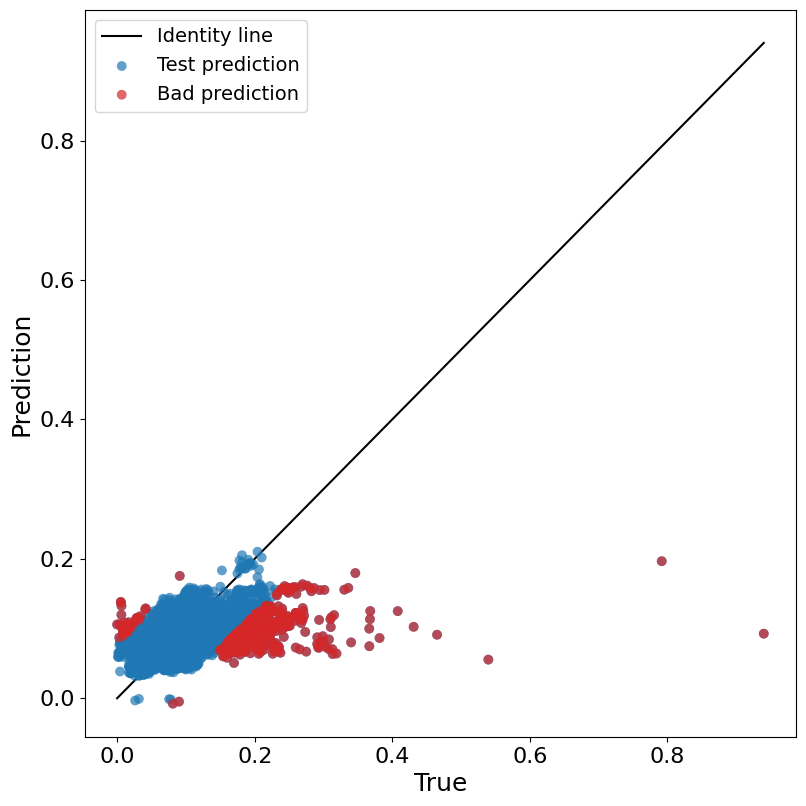

In [313]:
plt.figure(figsize=(8, 8))

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', label='Identity line')
plt.scatter(y_test.values, baseline_prediction, color='tab:blue', alpha=0.7, label='Test prediction', zorder=3, edgecolors='none', s=50)
plt.scatter(bad_y, baseline_model.predict(bad_X), color='tab:red', alpha=0.7, label='Bad prediction', zorder=3, edgecolors='none', s=50)

plt.xlabel('True')
plt.ylabel('Prediction')
plt.legend()

plt.tight_layout(pad=0.5)
# plt.savefig('images/prediction_bad_moscow_0_3.pdf', dpi=300)
plt.show()

In [138]:
# plt.figure(figsize=(8, 8))

# plt.scatter(X_ex.iloc[:, 0], X_ex.iloc[:, 1], alpha=0.7, edgecolors='none', s=50, color='tab:blue', label='Good points')
# plt.scatter(bad_X.iloc[:, 0], bad_X.iloc[:, 1], color='red', alpha=0.7, edgecolors='none', s=50, label='Bad points')

# plt.xlabel('Feature 1')
# plt.ylabel('Feature 2')

# plt.xlim(0, 1)
# plt.ylim(0, 1)
# plt.legend()
# plt.tight_layout(pad=0.5)
# # plt.savefig('images/bad_X.pdf', dpi=300)
# plt.show()

In [1133]:
# bad_data = data.loc[bad_y.index]

In [565]:
# low = [0.0] * 10
# up = [1.0] * 10
# num1_copy = [0.3, 0.4, 0.4, 0.5, 0.1]
# num2_copy = [0.1, 0.1, 0.8, 0.8, 0.9]

# tools.cxTwoPoint(num1_copy, num2_copy)
# tools.cxUniform(num1_copy, num2_copy, indpb= 0.4)
# tools.cxUniform([0, 0, 1], [1, 0, 0], indpb= 0.4)

In [172]:
# import random
# from deap import tools

# def cxOneHotOX(ind1, ind2, feature_sizes):
#     """
#     Order-Based Crossover (OX) для OneHot-кодированных признаков.
    
#     Args:
#         ind1: первая особь (list)
#         ind2: вторая особь (list)
#         feature_sizes: список размеров каждого OneHot-блока
        
#     Returns:
#         Кортеж из двух особей с сохранением валидности OneHot-векторов
#     """
#     # Проверяем, что особи одинаковой длины
#     assert len(ind1) == len(ind2), "Особи должны быть одинаковой длины"
    
#     # Создаем копии для безопасности
#     child1 = ind1[:]
#     child2 = ind2[:]
    
#     # Определяем границы блоков
#     boundaries = []
#     start = 0
#     for size in feature_sizes:
#         end = start + size
#         boundaries.append((start, end))
#         start = end
    
#     # Для каждого признака (блока) применяем OX
#     for start, end in boundaries:
#         # Выбираем случайные точки разрыва в пределах блока
#         if end - start < 2:
#             continue  # Пропускаем блоки размером 1
            
#         a, b = random.sample(range(start, end), 2)
#         point1, point2 = min(a, b), max(a, b)
        
#         # Копируем сегменты между точками разрыва
#         segment1 = child1[point1:point2]
#         segment2 = child2[point1:point2]
        
#         # Создаем маски для определения позиций единиц
#         ones_pos1 = [i for i in range(start, end) if child1[i] == 1]
#         ones_pos2 = [i for i in range(start, end) if child2[i] == 1]
        
#         # Заменяем сегменты
#         child1[point1:point2] = segment2
#         child2[point1:point2] = segment1
        
#         # Восстанавливаем валидность OneHot-векторов
#         repair_onehot_block(child1, start, end, ones_pos1)
#         repair_onehot_block(child2, start, end, ones_pos2)
    
#     return child1, child2

# def repair_onehot_block(individual, start, end, original_ones_pos):
#     """
#     Восстанавливает валидность OneHot-блока после скрещивания.
#     """
#     block = individual[start:end]
    
#     # Проверяем сумму элементов в блоке
#     block_sum = sum(block)
    
#     if block_sum == 1:
#         return  # Блок уже валиден
    
#     if block_sum == 0:
#         # Если все элементы нулевые, восстанавливаем исходную позицию единицы
#         if original_ones_pos and start <= original_ones_pos[0] < end:
#             individual[original_ones_pos[0]] = 1
#         else:
#             # Или выбираем случайную позицию
#             pos = random.randint(start, end-1)
#             individual[pos] = 1
    
#     elif block_sum > 1:
#         # Если больше одной единицы, оставляем только одну
#         ones_positions = [i for i in range(start, end) if individual[i] == 1]
        
#         # Оставляем только первую единицу, остальные обнуляем
#         for i, pos in enumerate(ones_positions):
#             if i == 0:
#                 continue  # Первую единицу оставляем
#             individual[pos] = 0

# # Пример использования в DEAP
# toolbox.register("mate", cxOneHotOX, feature_sizes=[3, 4, 2])  # Пример: 3 признака с 3, 4 и 2 категориями

In [ ]:
# def cxOneHotByFeature(ind1, ind2, feature_sizes):
#     child1 = ind1[:]
#     child2 = ind2[:]
    
#     start = 0
#     for size in feature_sizes:
#         end = start + size
#         if random.random() < 0.5:  # 50% chance to swap the feature
#             child1[start:end], child2[start:end] = child2[start:end], child1[start:end]
#         start = end
    
#     return child1, child2

In [314]:
def custom_crossover_num(ind1, ind2, num_eta=10):
    num1_copy = copy.deepcopy(ind1)
    num2_copy = copy.deepcopy(ind1)

    low = [0.0] * len(num1_copy)
    up = [1.0] * len(num1_copy)
    tools.cxSimulatedBinaryBounded(num1_copy, num2_copy, eta=num_eta, low=low, up=up)

    ind1 = num1_copy
    ind2 = num2_copy

    return ind1, ind2


def custom_crossover_num_ord(ind1, ind2, cat_indpb=0.3, num_eta=10):
    cat1 = ind1[:length_cat_ordinal]
    cat2 = ind2[:length_cat_ordinal]
    num1 = ind1[length_cat_ordinal:]
    num2 = ind2[length_cat_ordinal:]

    cat1_copy = copy.deepcopy(list(cat1))
    cat2_copy = copy.deepcopy(list(cat2))
    num1_copy = copy.deepcopy(list(num1))
    num2_copy = copy.deepcopy(list(num2))

    tools.cxUniform(cat1_copy, cat2_copy, indpb=cat_indpb)

    low = [0.0] * len(num1_copy)
    up = [1.0] * len(num1_copy)
    tools.cxSimulatedBinaryBounded(num1_copy, num2_copy, eta=num_eta, low=low, up=up)

    ind1[:] = cat1_copy + num1_copy
    ind2[:] = cat2_copy + num2_copy

    return ind1, ind2


# def custom_crossover_num_ord_nominal(ind1, ind2, cat_indpb=0.3, num_eta=10):
#     onehot1 = ind1[:sum(length_cat_onehot)]
#     onehot2 = ind2[:sum(length_cat_onehot)]
#     cat1 = ind1[sum(length_cat_onehot) : sum(length_cat_onehot) + length_cat_ordinal]
#     cat2 = ind2[sum(length_cat_onehot) : sum(length_cat_onehot) + length_cat_ordinal]
#     num1 = ind1[-length_num:]
#     num2 = ind2[-length_num:]

#     cat1_copy = copy.deepcopy(list(cat1))
#     cat2_copy = copy.deepcopy(list(cat2))
#     num1_copy = copy.deepcopy(list(num1))
#     num2_copy = copy.deepcopy(list(num2))

#     tools.cxUniform(cat1_copy, cat2_copy, indpb=cat_indpb)

#     low = [0.0] * len(num1_copy)
#     up = [1.0] * len(num1_copy)
#     tools.cxSimulatedBinaryBounded(num1_copy, num2_copy, eta=num_eta, low=low, up=up)

#     ind1[:] = cat1_copy + num1_copy
#     ind2[:] = cat2_copy + num2_copy

#     return ind1, ind2

In [315]:
def custom_mutate_num(individual, weights, linear_coefs, target_direction, base_mutation_rate=0.8, mutation_strength=0.5):
    for i in range(len(individual)):
        mutation_prob = base_mutation_rate # * weights[i]
        
        if random.random() < mutation_prob:
            coef = linear_coefs[i]
            direction = 1 if coef * target_direction >= 0 else -1
            
            # noise = direction * abs(np.random.normal(0, weights[i] * mutation_strength))
            noise = direction * abs(np.random.normal(0, 0.1 * mutation_strength))
            individual[i] = max(0, min(1, individual[i] + noise))
                
    return individual,


def custom_mutate_num_ord(individual, bad_X, weights, linear_coefs, target_direction, base_mutation_rate=0.8, mutation_strength=0.5):
    for i in range(len(individual)):
        mutation_prob = base_mutation_rate #* weights[i]
        
        if random.random() < mutation_prob:
            if i < length_dict['length_cat_ordinal']: 
                individual[i] = random.sample(list(bad_X.iloc[:, i].unique()), 1)[0]
            else: 
                # idx = i - len(cat_cols_name)
                coef = linear_coefs[i]
                
                direction = 1 if coef * target_direction >= 0 else -1
                
                # noise = direction * abs(np.random.normal(0, weights[i] * mutation_strength))
                noise = direction * abs(np.random.normal(0, 0.1 * mutation_strength))
                individual[i] = max(0, min(1, individual[i] + noise))
                
    return individual,


# def custom_mutate(individual, weights, linear_coefs, target_direction, base_mutation_rate=0.8, mutation_strength=0.5):
#     for i in range(len(individual)):
#         mutation_prob = base_mutation_rate * weights[i]
        
#         if random.random() < mutation_prob:
#             if i < len(cat_cols_name): 
#                 individual[i] = random.sample(list(X_exp[cat_cols_name[i]].unique()), 1)[0]
#             else: 
#                 # idx = i - len(cat_cols_name)
#                 coef = linear_coefs[i]
                
#                 direction = 1 if coef * target_direction >= 0 else -1
                
#                 noise = direction * abs(np.random.normal(0, weights[i] * mutation_strength))
#                 individual[i] = max(0, min(1, individual[i] + noise))
                
#     return individual,

In [316]:
lr = LinearRegression(fit_intercept=False)
lr.fit(X_train.values, y_train.values)
linear_coefs = lr.coef_[0]

In [317]:
def augmentation(bad_X, bad_y, baseline_model, linear_coefs, length_dict, num_steps: int = 10):
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    creator.create("Individual", list, fitness=creator.FitnessMax)
    toolbox = base.Toolbox()

    if (length_dict['length_cat_ordinal'] == 0) and (length_dict['length_cat_onehot'] == []):
        for i in range(length_dict['length_num']):
            # toolbox.register(f"num_{i}", random.uniform, 0.0, 1.0)
            toolbox.register(f"num_{i}", random.sample, list(bad_X.iloc[:, i].unique()), 1)
            
        def make_individual():
            return creator.Individual(np.hstack([toolbox.__getattribute__(f"num_{i}")() for i in range(length_dict['length_num'])]))
            
        toolbox.register("individual", tools.initIterate, creator.Individual, make_individual)
        toolbox.register("population", tools.initRepeat, list, toolbox.individual)
        toolbox.register("mate", custom_crossover_num)
            
            
    elif (length_dict['length_cat_ordinal'] != 0) and (length_dict['length_cat_onehot'] == []):
        for i in range(len(cat_columns)):
            toolbox.register(f"cat_{i}", random.sample, list(bad_X.iloc[:, i].unique()), 1)
            
        for i in range(length_cat_ordinal, length_cat_ordinal + length_dict['length_num']):
            # toolbox.register(f"num_{i}", random.uniform, 0.0, 1.0)
            toolbox.register(f"num_{i - length_cat_ordinal}", random.sample, list(bad_X.iloc[:, i].unique()), 1)
            
        def make_individual():
            return np.hstack([toolbox.__getattribute__(f"cat_{i}")() for i in range(length_cat_ordinal)] + \
                [toolbox.__getattribute__(f"num_{i}")() for i in range(length_dict['length_num'])])
            
        toolbox.register("individual", tools.initIterate, creator.Individual, make_individual)
        toolbox.register("population", tools.initRepeat, list, toolbox.individual)
        toolbox.register("mate", custom_crossover_num_ord)
        
        
    else:
        return 0
        # for i, col in enumerate(cat_cols_name):
        #     toolbox.register(f"cat_{i}", random.sample, list(X[col].unique()), 1)
        
        # for i, col in enumerate(cat_cols_name):
        #     toolbox.register(f"cat_{i}", random.sample, list(X[col].unique()), 1)
            
        # for i in range(length_num):
        #     # toolbox.register(f"num_{i}", random.uniform, 0.0, 1.0)
        #     toolbox.register(f"num_{i}", random.sample, list(bad_X.iloc[:, i].unique()), 1)
            
        # def make_individual():
        #     return 0
            
        # toolbox.register("individual", tools.initIterate, creator.Individual, make_individual)
        # toolbox.register("population", tools.initRepeat, list, toolbox.individual)
        # toolbox.register("mate", custom_crossover_num_ord_nominal)
        
        


    # def make_individual():
    #     if (length_cat_ordinal == 0) and (length_cat_onehot == []):
    #         return np.hstack([toolbox.__getattribute__(f"num_{i}")() for i in range(length_num)])
            
    #     elif (length_cat_ordinal != 0) and (length_cat_onehot == []):
    #         return np.hstack([toolbox.__getattribute__(f"cat_{i}")() for i in range(length_cat_ordinal)] + \
    #             [toolbox.__getattribute__(f"num_{i}")() for i in range(length_num)])
            
    #     else:
    #         return 0

    toolbox.register("select", tools.selTournament, tournsize=3)
    
    steps = tqdm(range(len(bad_X)))
    best_individuals = []
    bad_y_sc_arr = []
    prediction_exp = baseline_model.predict(bad_X)
    
    

    for _ in range(num_steps):
        bad_y_scenario = np.maximum(np.minimum(0.0, y_test.min().values[0]),
                                    np.minimum(bad_y + np.random.normal(0, 0.01, (len(bad_y), 1)), np.maximum(1.0, y_test.max().values[0])))
        # bad_y_scenario = bad_y
        
        for i in steps:
            def eval_func(individual, y_target, linear_coefs, weights, target_direction, bonus_factor = 0.9):
                prediction = baseline_model.predict([individual])
                error = 0.5 * (prediction[0] - y_target.values[i])**2 - np.mean( (individual - bad_X.values[i])**2 )
                # bonus = 0
                # for k, val in enumerate(individual):
                #     # if k > len(cat_cols_name):
                #         coef = linear_coefs[k]
                #         base_val = X_exp.loc[idx_sc].iloc[i, k+1]
                        
                
                #         if coef * target_direction >= 0:  # Увеличение признака повышает таргет
                #             if val > base_val:
                #                 bonus += weights[k] * (val - base_val) * bonus_factor
                #         elif coef * target_direction < 0:  # Уменьшение признака повышает таргет
                #             if val < base_val:
                #                 bonus += weights[k] * (base_val - val) * bonus_factor
                                
                total_fitness = error #+ bonus
                return (total_fitness,)
            
            def main(target_direction, y_target):
                toolbox.register("evaluate", eval_func, y_target=y_target, 
                                linear_coefs=linear_coefs, weights=1, target_direction=target_direction)
                # toolbox.unregister("mutate")
                if length_dict['length_cat_ordinal'] == 0:
                    toolbox.register("mutate", custom_mutate_num, weights=1, linear_coefs=linear_coefs, 
                                target_direction=target_direction)
                else:
                    toolbox.register("mutate", custom_mutate_num_ord, bad_X=bad_X, weights=1, linear_coefs=linear_coefs, 
                                target_direction=target_direction)

                pop = toolbox.population(n=30)
                hof = tools.HallOfFame(1, similar=np.array_equal)
                stats = tools.Statistics(lambda ind: ind.fitness.values)
                stats.register("avg", lambda x: sum(i[0] for i in x)/len(x))
                stats.register("max", lambda x: max(i[0] for i in x))

                algorithms.eaSimple(pop, toolbox, 0.1, 0.1, 10, stats=stats, halloffame=hof, verbose=False)
                
                return hof[0]
        
            if bad_y_scenario.values[i] >= prediction_exp[i]:
                target_direction = 1
            else:
                target_direction = -1
            
            
            best_individual = main(target_direction, bad_y_scenario)
            best_individuals.append(best_individual)
            
        bad_y_sc_arr.append(bad_y_scenario.values.flatten())
        
    bad_y_sc_arr = np.hstack(bad_y_sc_arr)
    best_individuals = np.array(best_individuals)
    
    return best_individuals, bad_y_sc_arr

In [318]:
best_individuals, bad_y_sc_arr = augmentation(bad_X, bad_y, baseline_model, linear_coefs, length_dict, num_steps=10)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
  0%|          | 0/435 [00:00<?, ?it/s]/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
100%|██████████| 435/435 [00:06<00:00, 70.13it/s]


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


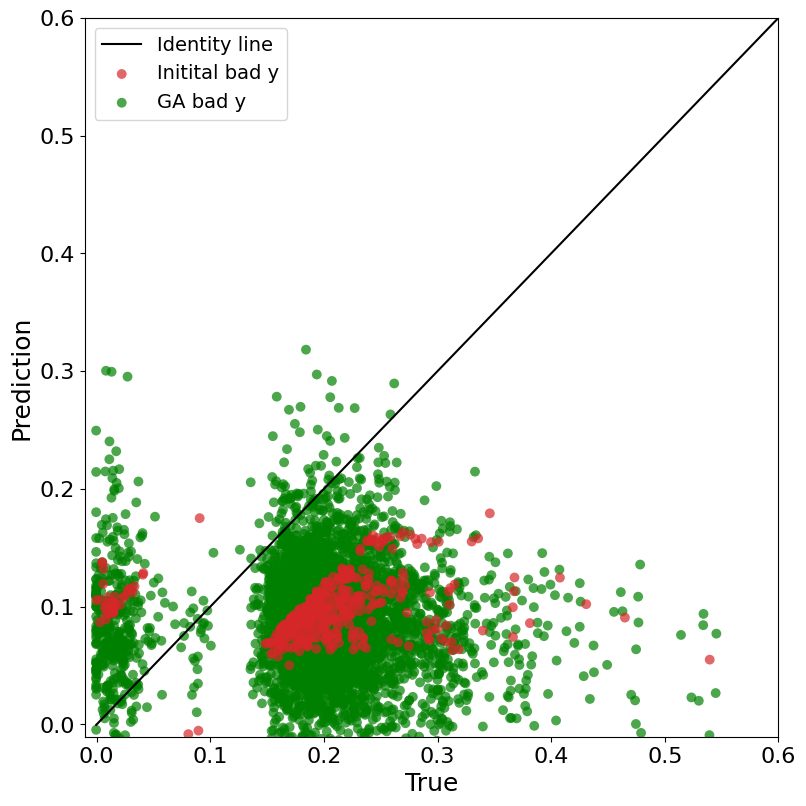

In [319]:
plt.figure(figsize=(8, 8))

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', label='Identity line')
plt.scatter(bad_y, baseline_model.predict(bad_X), alpha=0.7, label='Initital bad y', color='tab:red', zorder=3, edgecolors='none', s=50)
plt.scatter(bad_y_sc_arr, baseline_model.predict(best_individuals), alpha=0.7, label='GA bad y', color='green', edgecolors='none', s=50)

plt.xlabel('True')
plt.ylabel('Prediction')
plt.legend()
plt.ylim((y_test.min().values - 0.01, 0.6))
plt.xlim((y_test.min().values - 0.01, 0.6))

plt.tight_layout(pad=0.5)
# plt.savefig('images/prediction_best_ind_moscow_0_02.pdf', dpi=300)
plt.show()

In [101]:
print(pd.DataFrame(np.array([[mean_squared_error(bad_y.values.flatten(), baseline_model.predict(bad_X.values).flatten()),
               mean_squared_error(bad_y_sc_arr.flatten(), baseline_model.predict(best_individuals).flatten())],
                       
                [wasserstein_distance(bad_y.values.flatten(), baseline_model.predict(bad_X.values).flatten()),
                 wasserstein_distance(bad_y_sc_arr.flatten(), baseline_model.predict(best_individuals).flatten())],
                
                [np.mean(list(map(lambda x, y: wasserstein_distance(x, y), bad_X.values, bad_X.values))),
                 np.mean(list(map(lambda x, y: wasserstein_distance(x, y), bad_X.values, best_individuals)))],
                
                [np.var(bad_y.values.flatten() - baseline_model.predict(bad_X.values).flatten()),
                 np.var(bad_y_sc_arr.flatten() - baseline_model.predict(best_individuals).flatten())]
              
              ]).T, columns=['MSE', 'W_distance_y', 'W_distance_X', 'Residual Var'], index=['True', 'GA']).round(3).to_latex(float_format="%.3f"))

\begin{tabular}{lrrrr}
\toprule
 & MSE & W_distance_y & W_distance_X & Residual Var \\
\midrule
True & 0.029 & 0.153 & 0.000 & 0.006 \\
GA & 0.041 & 0.170 & 0.092 & 0.012 \\
\bottomrule
\end{tabular}



In [174]:
# plt.figure(figsize=(8, 8))

# plt.scatter(X_ex.iloc[:, 0], X_ex.iloc[:, 1], alpha=0.7, edgecolors='none', s=50, color='tab:blue', label='Good points')
# plt.scatter(best_individuals[:, 0], best_individuals[:, 1], color='green', alpha=0.7, edgecolors='none', s=50, label='GA points')
# plt.scatter(bad_X.iloc[:, 0], bad_X.iloc[:, 1], color='red', alpha=0.7, edgecolors='none', s=50, label='Bad points')

# plt.xlabel('Feature 1')
# plt.ylabel('Feature 2')

# plt.xlim(0, 1)
# plt.ylim(0, 1)
# plt.legend()
# plt.tight_layout(pad=0.5)
# # plt.savefig('images/GA_points.pdf', dpi=300)
# plt.show()

In [576]:
y_test.min().values

array([0.0007624])

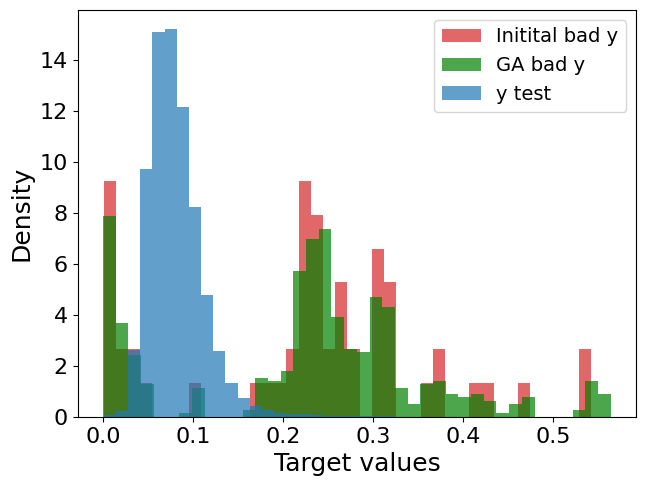

In [237]:
plt.hist(bad_y, bins=40, density=True, alpha=0.7, label='Initital bad y', color='tab:red')
plt.hist(bad_y_sc_arr, bins=40, density=True, alpha=0.7, label='GA bad y', color='green')
plt.hist(y_test, bins=40, density=True, alpha=0.7, label='y test', color='tab:blue')


plt.legend()
plt.xlabel('Target values')
plt.ylabel('Density')

plt.tight_layout(pad=0.5)
# plt.savefig('images/hist_ga_moscow_0_1.pdf', dpi=300)
plt.show()

In [26]:
# for i in range(len(X_train.columns)):
#     plt.hist(X_ex.iloc[:, i], bins=40, alpha=0.6, label='Initital X', color='black', density=True)
#     plt.hist(bad_X.iloc[:, i], bins=40, alpha=0.6, label='Initital bad X', color='tab:red', density=True)
#     plt.hist(np.array(best_individuals)[:, i], bins=40, alpha=0.6, label='Scenario bad X', color='tab:blue', density=True)

#     plt.legend()
#     plt.show()

In [408]:
# plt.subplots(figsize=(10, 5))

# vis_arr1 = []
# vis_arr2 = []

# for col in X_exp.columns.values:
#     vis_arr1.append((data.loc[idx_sc, col]/data.loc[idx_sc, col].max()).mean())
#     vis_arr2.append((scenario_df_GA[col]/scenario_df_GA[col].max()).mean())
#     # 
# plt.bar(X_exp.columns, vis_arr1, alpha=0.6, color='tab:blue', label='Initial data')
# plt.bar(X_exp.columns, vis_arr2, alpha=0.6, color='tab:red', label='Synth data')

# plt.xticks(rotation=90, fontsize=10)
# plt.ylabel('Mean value')
# plt.legend()
# plt.show()

In [40]:
bad_X.shape

(230, 16)

In [41]:
best_individuals.shape

(2300, 16)

In [320]:
bad_X_ga, bad_y_ga = select_bad_examples(pd.DataFrame(best_individuals), pd.DataFrame(bad_y_sc_arr), 
                                         baseline_model.predict(best_individuals),
                                         0.08)

In [321]:
bad_X_ga

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,4.0,0.307035,0.455556,0.118970,0.075973,0.109758,0.036576,0.466303,0.611588,0.034567,0.125533,0.225237,0.711091,0.047386,0.580538,0.024588
3,5.0,0.251106,0.166667,0.126637,0.221446,0.144413,0.304781,0.596990,0.531823,0.269886,0.102504,0.504409,0.237890,0.199166,0.486933,0.156480
4,4.0,0.308531,0.545502,0.097623,0.216692,0.497146,0.249610,0.584922,0.549512,0.275917,0.104810,0.690616,0.368166,0.000148,0.497870,0.014127
5,7.0,0.118214,0.536530,0.172268,0.287799,0.121044,0.320982,0.565444,0.578394,0.443946,0.070782,0.668850,0.072366,0.741249,0.341466,0.081811
6,5.0,0.031859,0.265141,0.115311,0.243638,0.175348,0.369226,0.410086,0.487460,0.220779,0.093371,0.194007,0.927565,0.911960,0.564606,0.035704
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4342,5.0,0.206223,0.533626,0.317011,0.041542,0.169614,0.311826,0.515897,0.538576,0.106060,0.221840,0.310086,0.949820,0.961478,0.447309,0.055048
4345,4.0,0.416487,0.515379,0.182691,0.797156,0.314999,0.648836,0.627079,0.583146,0.425134,0.133705,0.186721,1.000000,0.470210,0.586153,0.149158
4346,4.0,0.123581,0.369660,0.174700,0.126148,0.106331,0.135005,0.430975,0.629361,0.040630,0.047186,0.566736,0.789592,0.846915,0.690542,0.033896
4347,15.0,0.042168,0.175533,0.198765,0.102169,0.246834,0.032018,0.457025,0.360787,0.435170,0.150559,0.712424,0.964833,0.000000,0.528108,0.163046


In [322]:
idx_rnd = np.arange(len(bad_X) + len(bad_X_ga))
np.random.shuffle(idx_rnd)

augmented_X = np.concatenate([bad_X.values, bad_X_ga.values])[idx_rnd]
augmented_y = np.concatenate([bad_y.values.flatten(), bad_y_ga.values.flatten()])[idx_rnd]

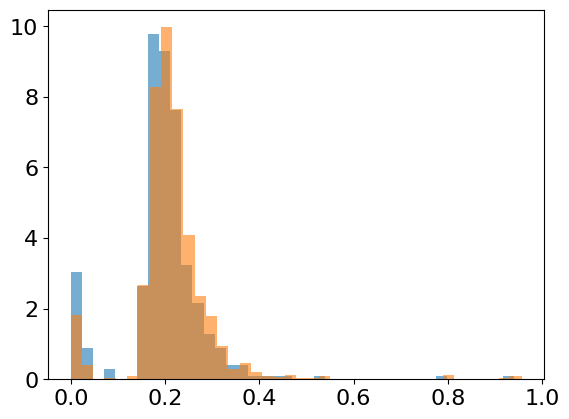

In [323]:
# plt.hist(y_test, density=True, alpha=0.6, bins=40)
plt.hist(bad_y, density=True, alpha=0.6, bins=40)
plt.hist(augmented_y, bins=40, density=True, alpha=0.6)
plt.show()

In [324]:
augmented_data = np.concatenate([augmented_X, augmented_y.reshape(-1, 1)], axis=1)

In [325]:
augmented_data.shape

(3592, 17)

## Generator

In [326]:
# scaler = MinMaxScaler()
# bad_data = scaler.fit_transform(bad_data)
data_tensor = np.array(augmented_data).astype('float32')
data_tensor = torch.tensor(data_tensor)

In [327]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Residual block
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=3, padding='same')
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size=3, padding='same')
        self.bn2 = nn.BatchNorm1d(channels)
        
        self.act = nn.SiLU()
        
        self.drop1 = nn.Dropout(0.1)
        self.drop2 = nn.Dropout(0.1)

    def forward(self, x):
        skip = x
        out = self.conv1(x)
        out = self.act(out)
        out = out + skip
        out = self.act(out)
        out = self.bn1(out)
        out = self.drop1(out)
        
        # skip2 = out
        # out = self.conv2(out)
        # out = self.act(out)
        # out = out + skip2
        # out = self.act(out)
        # out = self.bn2(out)
        # out = self.drop2(out)
        
        return out

# VAE model definition
class VAE(nn.Module):
    def __init__(self, input_channels=1, seq_length=128, latent_dim=16, hidden_channels=32, cat_cardinalities: list = []):
        super(VAE, self).__init__()
        
        self.seq_length = seq_length
        self.latent_dim = latent_dim
        self.hidden_channels = hidden_channels
        
        
        
        if not cat_cardinalities:
            self.cat_flag = False
            self.h_dim_enc = seq_length * hidden_channels
            self.decoder_reshape_dim = self.seq_length
            self.n_cat = 0
            
        else:
            self.cat_flag = True
            self.emb_dim = 4
            self.n_cat = len(cat_cardinalities)
            self.h_dim_dec = 2**9
            # self.decoder_reshape_dim = (self.h_dim_dec + (self.emb_dim - 1) * self.n_cat)
            self.decoder_reshape_dim = self.h_dim_dec // self.hidden_channels
            self.cat_heads = nn.ModuleList([nn.Linear(self.emb_dim - 1, card) for card in cat_cardinalities])

            # self.decoder_with_logit_dim = 
            
            self.embeddings = []
            for card in cat_cardinalities:
                self.embeddings.append(nn.Embedding(card, self.emb_dim))
                
            self.h_dim_enc = (seq_length + (self.emb_dim - 1) * self.n_cat) * hidden_channels 
        

        
        self.enc_conv1 = nn.Conv1d(input_channels, hidden_channels, kernel_size=3, padding='same')
        self.enc_bn1 = nn.BatchNorm1d(hidden_channels)
        self.enc_res1 = ResidualBlock(hidden_channels)
   
        self.enc_conv2 = nn.Conv1d(hidden_channels, hidden_channels, kernel_size=3, padding='same')
        self.enc_bn2 = nn.BatchNorm1d(hidden_channels)
        self.enc_res2 = ResidualBlock(hidden_channels)

        
        
        self.fc_mu = nn.Sequential(nn.Linear(self.h_dim_enc, latent_dim))
        self.fc_logvar = nn.Sequential(nn.Linear(self.h_dim_enc, latent_dim))
        # self.fc_mu = nn.Sequential(nn.Linear(latent_dim, latent_dim))
        # self.fc_logvar = nn.Sequential(nn.Linear(latent_dim, latent_dim))
        self.fc_decode = nn.Sequential(nn.Linear(latent_dim, self.h_dim_dec))


        self.dec_conv1 = nn.ConvTranspose1d(hidden_channels, hidden_channels, kernel_size=3, padding=1, output_padding=0)
        self.dec_bn1 = nn.BatchNorm1d(hidden_channels)
        self.dec_res1 = ResidualBlock(hidden_channels)
    
        self.dec_conv2 = nn.ConvTranspose1d(hidden_channels, hidden_channels, kernel_size=3, padding=1, output_padding=0)
        self.dec_res2 = ResidualBlock(hidden_channels)
        self.dec_conv3 = nn.ConvTranspose1d(hidden_channels, input_channels, kernel_size=1)
        
        self.act = nn.SiLU()
        
        self.condition_encoder_beta = nn.Sequential(
            nn.Linear(1, 2**6),
            self.act,
            nn.Linear(2**6, latent_dim),
            self.act
        )
        
        self.condition_encoder_gamma = nn.Sequential(
            nn.Linear(1, 2**6),
            self.act,
            nn.Linear(2**6, latent_dim),
            self.act
        )
        
        # self.condition_decoder_beta = nn.Sequential(
        #     nn.Conv1d(1, hidden_channels, kernel_size=3, padding='same'),
        #     self.act,
        #     nn.Linear(1, 2**6),
        #     self.act,
        #     nn.Linear(2**6, self.seq_length + self.emb_dim - 1),
        #     self.act
        # )
        
        # self.condition_decoder_gamma = nn.Sequential(
        #     nn.Conv1d(1, hidden_channels, kernel_size=3, padding='same'),
        #     self.act,
        #     nn.Linear(1, 2**6),
        #     self.act,
        #     nn.Linear(2**6, self.seq_length + self.emb_dim - 1),
        #     self.act
        # )
        
        self.condition_decoder_beta = nn.Sequential(
            nn.Conv1d(1, hidden_channels, kernel_size=3, padding='same'),
            self.act,
            nn.Linear(1, 2**6),
            self.act,
            nn.Linear(2**6, self.decoder_reshape_dim),
            self.act
        )
        
        self.condition_decoder_gamma = nn.Sequential(
            nn.Conv1d(1, hidden_channels, kernel_size=3, padding='same'),
            self.act,
            nn.Linear(1, 2**6),
            self.act,
            nn.Linear(2**6, self.decoder_reshape_dim),
            self.act
        )
        
        
            
        # if self.cat_flag:
            # self.embedding = nn.Embedding(len(scalers['ord_encoder'].categories_[0]), 2)

        self.proj = nn.Sequential(nn.Linear(self.decoder_reshape_dim - (self.emb_dim - 1) * self.n_cat, 2**6),
                                  self.act,
                                  nn.Linear(2**6, 2**6),
                                  self.act,
                                  nn.Linear(2**6, self.seq_length - self.n_cat))
    
        # self.decoder_proj = nn.Linear(self.decoder_reshape_dim, )
        

    def encode(self, x, y):
        # x: (B, 1, T), y: (B, 1, 1)
        if self.cat_flag:
            emb_list = []
            for i, emb in enumerate(self.embeddings):
                emb_list.append(emb(x[:,:,i].long()))
            emb_list = torch.cat(emb_list, dim=2)
            
            x = torch.cat([x[:,:, self.n_cat:], emb_list], dim=2) #(B, 1, T + (emb_dim - 1) * n_cat)
            
        
        x = self.enc_conv1(x)
        x = self.act(x)
        x = self.enc_res1(x) #(B, hidden_channels, T + (emb_dim - 1) * n_cat)
        
        x = self.enc_conv2(x)
        x = self.act(x)
        x = self.enc_res2(x) #(B, hidden_channels, T + (emb_dim - 1) * n_cat)
  
        x = x.view(x.size(0), -1) #(B, hidden_channels * (T + (emb_dim - 1) * n_cat))
        
        mu = self.fc_mu(x) * self.condition_encoder_beta(y).squeeze(1) + self.condition_encoder_gamma(y).squeeze(1) #(B, latent_dim)
        logvar = self.fc_logvar(x) * self.condition_encoder_beta(y).squeeze(1) + self.condition_encoder_gamma(y).squeeze(1) #(B, latent_dim)
        
        return mu, logvar
    

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std


    def decode(self, z, y):
        # z: (B, latent_dim), y: (B, 1, 1)
        
        x = self.fc_decode(z) #(B, h_dim_dec)
        x = x.view(z.size(0), self.hidden_channels, self.decoder_reshape_dim) #(B, hidden_channel, h_dim_dec//hidden_channel)
        
        x = self.dec_conv1(x) #(B, hidden_channel, h_dim_dec//hidden_channel)
        
        x = self.act(x)
        x = self.dec_res1(x)
        x = self.dec_conv2(x) #(B, hidden_channel, h_dim_dec//hidden_channel)
        
        
        x = self.dec_res2(x) * self.condition_decoder_beta(y) + self.condition_decoder_gamma(y)
        x = self.dec_conv3(x) #(B, 1, h_dim_dec//hidden_channel)
        
        x_cat, x_num = x[:,:, :(self.emb_dim - 1) * self.n_cat], x[:,:, (self.emb_dim - 1) * self.n_cat:] 
        #x_cat: (B, 1, (emb_dim - 1) * n_cat), x_num: (B, 1, T - (emb_dim - 1) * n_cat)
        cat_logits = [head(x_cat) for head in self.cat_heads] if self.n_cat > 0 else []

        x_num = self.proj(x_num) #(B, 1, T - n_cat)
        
        return x_num, cat_logits
    

    def forward(self, x):
        x, y = x[:,:,:-1], x[:,:,-1].unsqueeze(1)
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        recon_x_num, recon_x_logits = self.decode(z, y)
        
        return recon_x_num, recon_x_logits, mu, logvar
    

def vae_loss(recon_x_num, recon_x_logits, x, mu, logvar, beta, cat_target_flag=False):
    if cat_target_flag:
        recon_num = F.mse_loss(recon_x_num, x[:,:, length_dict['length_cat_ordinal']:-1], reduction='mean')
      
        x_cat = x[:, :, :length_dict['length_cat_ordinal']].squeeze(1).long().transpose(0, 1)

        # Categorical cross-entropy
        recon_cat = torch.tensor(0.0, device=device)
        recon_x_logits = recon_x_logits
     
        cat_losses = []
        for logits, tgt in zip(recon_x_logits, x_cat):
            # logits: [B, card], tgt: [B]
            cat_losses.append(F.cross_entropy(logits.squeeze(1), tgt, reduction='mean'))
        recon_cat = torch.stack(cat_losses).sum()
            
        recon_loss = recon_num + 0.1 * recon_cat
        
    else:
        recon_loss = F.mse_loss(recon_x_num, x[:,:, :-1], reduction='mean')

    
    # kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    kl_loss = torch.mean( -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp() , dim=1) )
    
    return recon_loss + beta * kl_loss

In [328]:
def train_vae(data_tensor, num_epochs = 200, learning_rate = 1e-3, batch_size = 2**6, input_channels = 1, cat_target_flag = True):
    seq_length = data_tensor.size(1) - 1
    train_loader = torch.utils.data.DataLoader(data_tensor.unsqueeze(1), batch_size=batch_size, shuffle=True)

    model_vae = VAE(input_channels=input_channels, seq_length=seq_length, latent_dim=256, hidden_channels=16, cat_cardinalities=[27])
    model_vae.to(device)
    optimizer = optim.AdamW(model_vae.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-4)
    beta_sch = torch.cat([torch.tensor(np.linspace(0.0, 0.0005, num_epochs//2)), torch.tensor(np.linspace(0.0005, 0.001, num_epochs//2))]).float().to(device)
    
    epochs = tqdm(range(num_epochs))
    
    losses = []
    model_vae.train()
    
    for epoch in epochs:
        epoch_loss = 0
        
        for _, data in enumerate(train_loader):
            data = data.to(device)
            
            recon_x_num, recon_x_logits, mu, logvar = model_vae(data)
            loss = vae_loss(recon_x_num, recon_x_logits, data, mu, logvar, beta_sch[epoch], cat_target_flag)
            
            optimizer.zero_grad()
            loss.backward()
            norm = torch.nn.utils.clip_grad_norm_(model_vae.parameters(), max_norm=3)
            optimizer.step()
        
            epoch_loss += loss.item()
            
        scheduler.step()
        
        
        avg_loss = epoch_loss / len(train_loader.dataset)
        losses.append(avg_loss)
     
        if epoch % 2 == 0:
            epochs.set_description(f'Average Loss: {avg_loss:.4f}, LR: {round(optimizer.param_groups[0]["lr"], 4)}')
            
    return model_vae, losses

In [329]:
model_vae, losses = train_vae(data_tensor)

Average Loss: 0.0005, LR: 0.0001: 100%|██████████| 200/200 [05:21<00:00,  1.61s/it]


In [335]:
seq_length = len(augmented_data[0]) - 1
input_channels = 1
sum([p.numel() for p in model_vae.parameters()]) / 1e6

0.342044

In [336]:
# from torchsummary import summary
# summary(model_vae, input_size=(1, seq_length + 1))

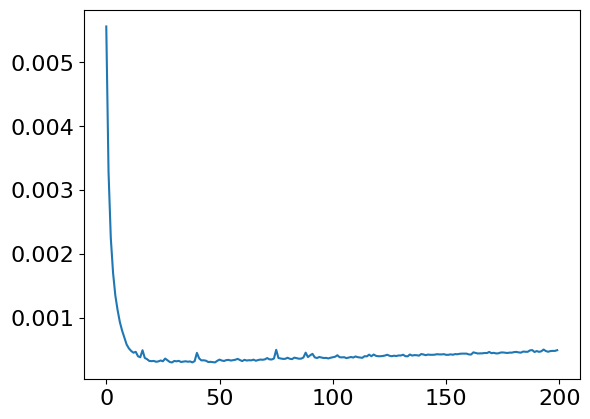

In [337]:
plt.plot(losses[:])
plt.show()

In [338]:
def generate(model, data_tensor, mult: int = 5) -> np.array:
    synth_vae_arr = []

    for _ in range(mult):
        synth_vae_num, synth_vae_logits, _, _ = model(data_tensor.unsqueeze(1).to(device))
        synth_vae_num = synth_vae_num.squeeze(1).detach().cpu().numpy()
        
        cat_arr = []
        for logits in synth_vae_logits:
            cat_arr.append(logits.squeeze(1).softmax(dim=-1).argmax(dim=-1).long().view(-1, 1).detach().cpu().numpy())
        cat_arr = np.hstack(np.array(cat_arr))
        
        synth_vae = np.concatenate([cat_arr, synth_vae_num], axis=1)
        
        synth_vae_arr.append(synth_vae)
        
    synth_vae = np.vstack(np.array(synth_vae_arr))
    
    return synth_vae #(5*N, T)

In [339]:
model_vae.eval()

VAE(
  (cat_heads): ModuleList(
    (0): Linear(in_features=3, out_features=27, bias=True)
  )
  (enc_conv1): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=same)
  (enc_bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (enc_res1): ResidualBlock(
    (conv1): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=same)
    (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=same)
    (bn2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): SiLU()
    (drop1): Dropout(p=0.1, inplace=False)
    (drop2): Dropout(p=0.1, inplace=False)
  )
  (enc_conv2): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=same)
  (enc_bn2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (enc_res2): ResidualBlock(
    (conv1): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=same)
   

In [340]:
synth_vae = generate(model_vae, data_tensor)
synth_vae.shape

(17960, 16)

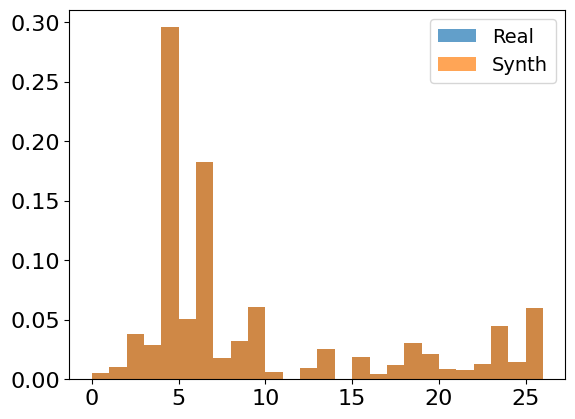

In [341]:
plt.hist(augmented_data[:, 0], bins=np.arange(0, 27), alpha=0.7, density=True, label='Real')
plt.hist(synth_vae[:, 0], bins=np.arange(0, 27), alpha=0.7, density=True, label='Synth')

plt.legend()
plt.show()

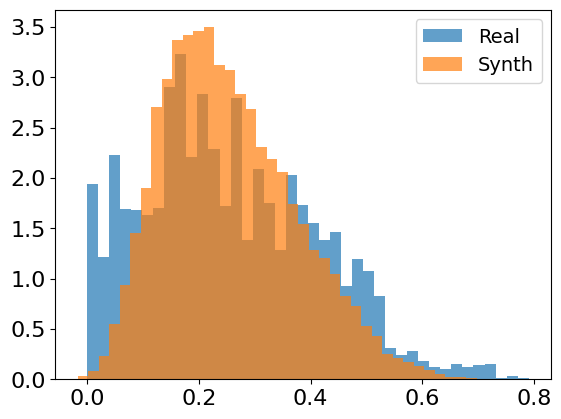

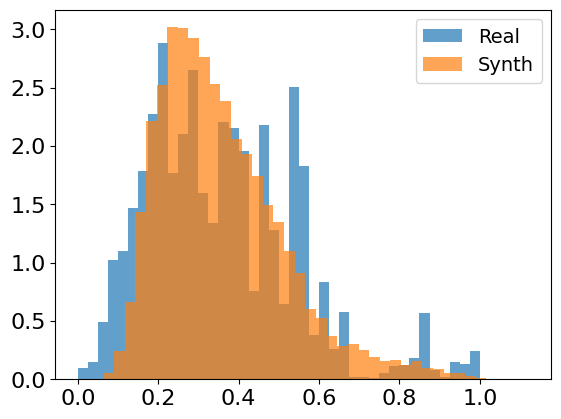

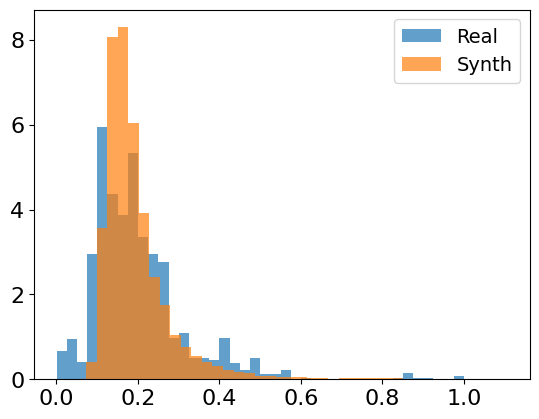

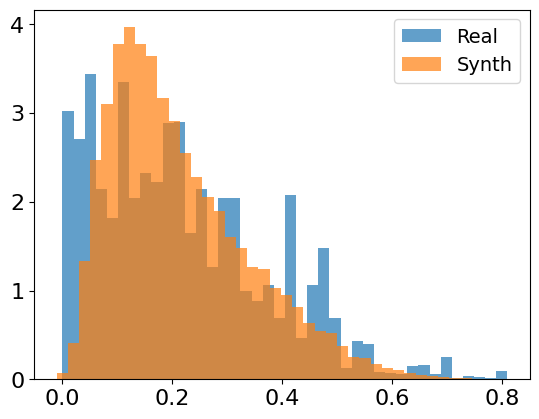

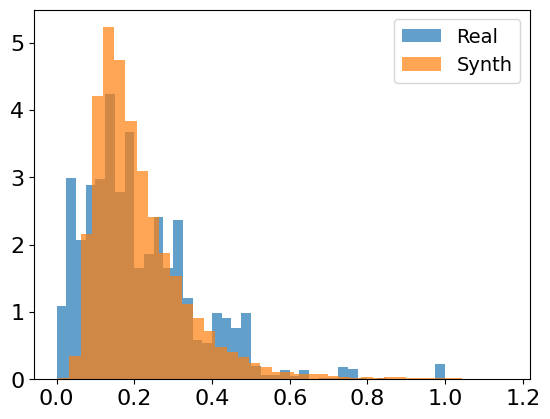

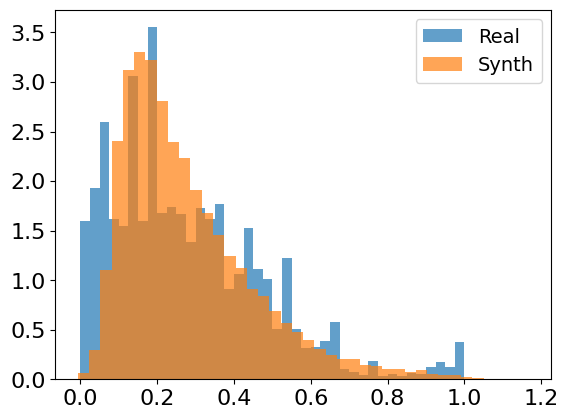

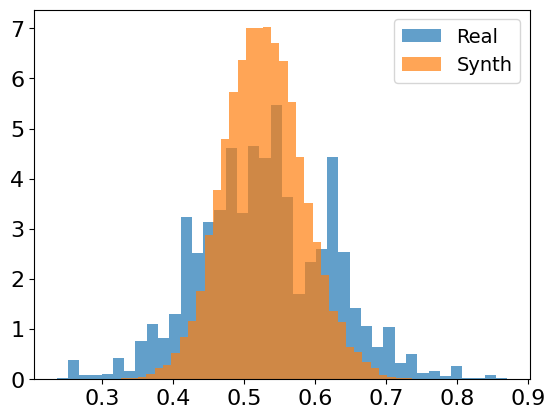

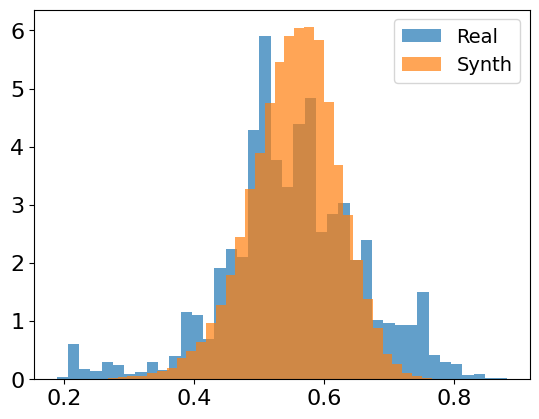

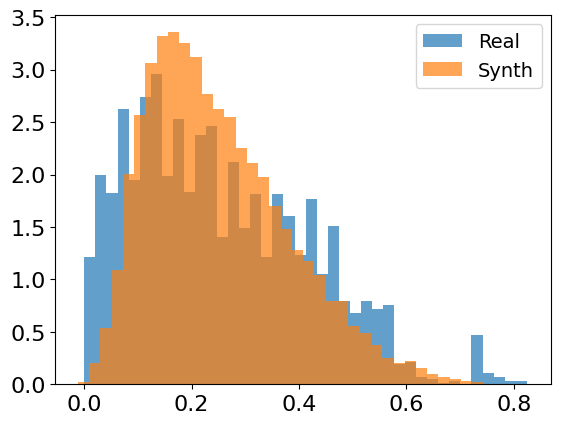

In [342]:
for i in range(1, 10):
    plt.hist(augmented_data[:, i], bins=40, alpha=0.7, density=True, label='Real')
    plt.hist(synth_vae[:, i], bins=40, alpha=0.7, density=True, label='Synth')

    plt.legend()
    plt.show()

In [343]:
# synth_df = pd.DataFrame(np.concatenate([scaler_X_train.inverse_transform(synth_vae[:, :-1]), scaler_y_train.inverse_transform(synth_vae[:, -1].reshape(-1, 1))], axis=1), columns=data.columns)
# synth_df = pd.DataFrame(np.concatenate([scalers['scaler_X'].inverse_transform(synth_vae), scalers['scaler_y'].inverse_transform(data_tensor[:, -1].repeat(5).reshape(-1, 1))], axis=1))
synth_df = pd.DataFrame(np.concatenate([synth_vae, data_tensor[:, -1].repeat(5).reshape(-1, 1)], axis=1))

In [344]:
bad_D = pd.concat([bad_X, bad_y], axis=1)
bad_D = bad_D.rename(columns={0: 'target'})

In [345]:
bad_D['Квартиры среднего качества (типовые)'] = bad_D['Квартиры среднего качества (типовые)'].astype(int).astype(str)

In [346]:
augmented_df = pd.DataFrame(copy.deepcopy(augmented_data), columns=bad_D.columns)
augmented_df['Квартиры среднего качества (типовые)'] = augmented_df['Квартиры среднего качества (типовые)'].astype(int).astype(str)

In [ ]:
# import prince

# famd = prince.FAMD(
#         n_components=2,  # Number of dimensions to reduce to
#         n_iter=3,        # Number of iterations for the algorithm
#         copy=True,
#         check_input=True,
#         random_state=42, # For reproducibility
#         engine="sklearn",
#         handle_unknown="ignore" # How to handle unknown categories during transform
#     )



# synth_df_str = copy.deepcopy(synth_df)
# synth_df_str[0] = synth_df_str[0].astype(int).astype(str)
# synth_df_str.columns = bad_D.columns

good_df = pd.concat([X_test.loc[np.setdiff1d(X_test.index.values, bad_X.index.values)],
           pd.DataFrame(y_test.loc[np.setdiff1d(X_test.index.values, bad_X.index.values)].values, columns=['target'])], axis=1).dropna()
good_df['Квартиры среднего качества (типовые)'] = good_df['Квартиры среднего качества (типовые)'].astype(int).astype('str')


# famd = famd.fit(good_df)
# pca_components1 = famd.transform(bad_D).values
# pca_components2 = famd.transform(augmented_df).values
# pca_components3 = famd.transform(synth_df_str).values
# pca_components4 = famd.transform(good_df).values

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, MinMaxScaler


# # pca = PCA(n_components=2)
# # pca_components1 = pca.fit_transform(bad_D.values[:, 1:])
# # pca_components2 = pca.transform(augmented_data[:, 1:])
# # pca_components3 = pca.transform(synth_df.values[:, 1:])

pca = TSNE(n_components=2, perplexity=15, init='pca', random_state=42)
X_combined = np.vstack([bad_D.values[:, :], augmented_data[:, :], synth_df.values[:, :], good_df.values[:, :]])
scaler = MinMaxScaler()
X_combined = scaler.fit_transform(X_combined)

pca_components = pca.fit_transform(X_combined)
pca_components1 = pca_components[:len(bad_D)]
pca_components2 = pca_components[len(bad_D):len(bad_D)+len(augmented_data)]
pca_components3 = pca_components[len(bad_D)+len(augmented_data):len(bad_D)+len(augmented_data)+len(synth_df)]
pca_components4 = pca_components[-len(good_df):]

In [480]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(pca_components1)

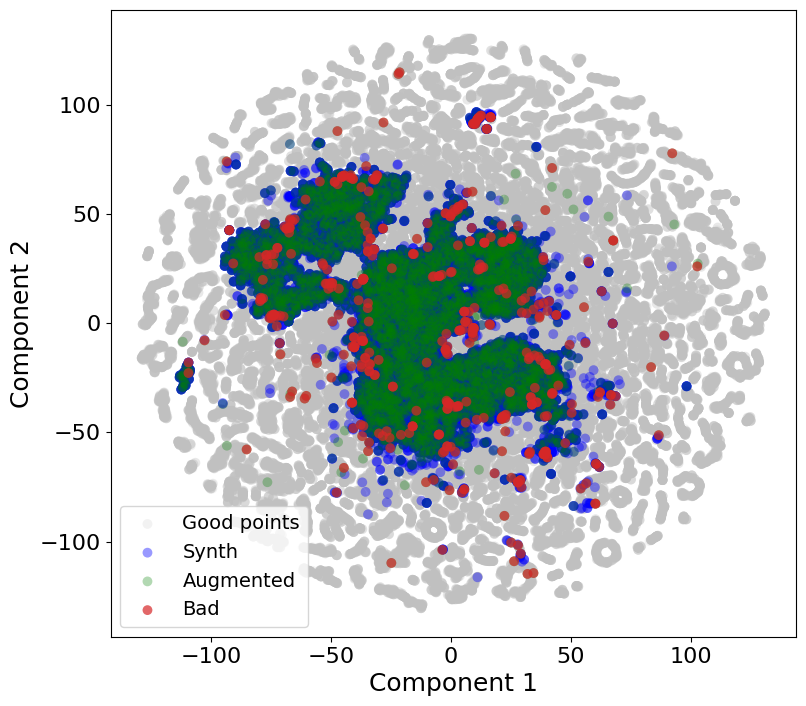

In [ ]:
plt.subplots(figsize=(8, 7))



plt.scatter(pca_components4[:, 0], pca_components4[:, 1], color='silver', alpha=0.2, label='Good points', edgecolors='none', s=50)


# plt.scatter(pca_components1[:, 0], pca_components1[:, 1], c=clusters, s=50, alpha=1, cmap='viridis', edgecolors='none', label='Clusters of bad points')
# plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='black', marker='X', s=200, label='Cluster centroids')


plt.scatter(pca_components3[:, 0], pca_components3[:, 1], color='blue', alpha=0.4, label='Synth', edgecolors='none', s=50)
plt.scatter(pca_components2[:, 0], pca_components2[:, 1], color='green', alpha=0.3, label='Augmented', edgecolors='none', s=50)
plt.scatter(pca_components1[:, 0], pca_components1[:, 1], color='tab:red', alpha=0.7, label='Bad', edgecolors='none', s=50)



plt.legend(loc='lower left')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.tight_layout(pad=0.5)
# plt.savefig('images/tsne_reg.pdf', dpi=300)
plt.show()

In [509]:
# plt.figure(figsize=(8, 8))

# plt.scatter(X_ex.iloc[:, 0], X_ex.iloc[:, 1], alpha=0.7, edgecolors='none', s=50, color='tab:blue', label='Good points')
# plt.scatter(best_individuals[:, 0], best_individuals[:, 1], color='green', alpha=0.7, edgecolors='none', s=50, label='GA points')
# plt.scatter(bad_X.iloc[:, 0], bad_X.iloc[:, 1], color='red', alpha=0.7, edgecolors='none', s=50, label='Bad points')
# plt.scatter(synth_df.iloc[:, 0], synth_df.iloc[:, 1], color='purple', alpha=0.5, edgecolors='none', s=50, label='VAE points')

# plt.xlabel('Feature 1')
# plt.ylabel('Feature 2')

# plt.xlim(0, 1)
# plt.ylim(0, 1)
# plt.legend()
# plt.tight_layout(pad=0.5)
# # plt.savefig('images/VAE_points.pdf', dpi=300)
# plt.show()

In [510]:
# bad_data['pricemetr'].hist(bins=40,  alpha=0.7, density=True)
# synth_df['pricemetr'].hist(bins=40, alpha=0.7, density=True)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


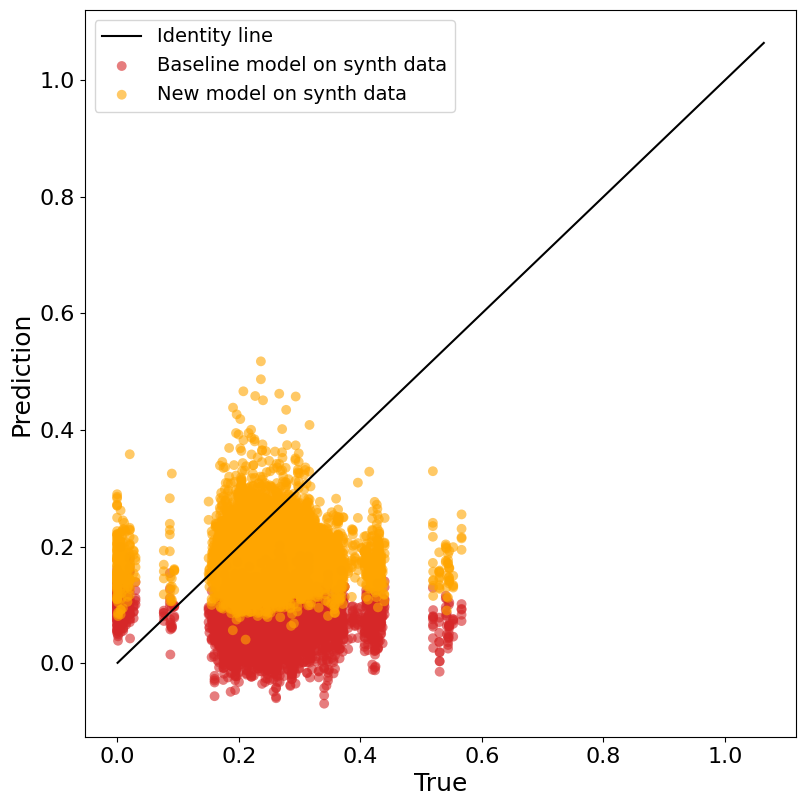

In [511]:
plt.subplots(figsize=(8, 8))
# synth_pred = xgb.predict(synth_df.drop('pricemetr', axis=1))
X_tilde = synth_df.iloc[:, :-1]
X_tilde.columns = X_train.columns

synth_pred = baseline_model.predict(X_tilde)
new_model_synth_pred = new_model.predict(X_tilde)

# plt.scatter(bad_y.values, xgb.predict(bad_X), alpha=0.6, label='Real bad X', color='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', label='Identity line')
# plt.scatter(augmented_y, baseline_model.predict(augmented_X), alpha=0.6, label='Baseline model on augmented data', color='tab:green', edgecolors='none', s=50)
# plt.scatter(augmented_y, new_model.predict(augmented_X), alpha=0.6, label='New model on augmented data', color='orange', edgecolors='none', s=50)
plt.scatter(synth_df.iloc[:, -1], synth_pred, alpha=0.6, label='Baseline model on synth data', color='tab:red', edgecolors='none', s=50)
plt.scatter(synth_df.iloc[:, -1], new_model_synth_pred, alpha=0.6, label='New model on synth data', color='orange', edgecolors='none', s=50)


plt.xlabel('True')
plt.ylabel('Prediction')
plt.legend()
plt.tight_layout(pad=0.5)
# plt.savefig('images/vae_prediction_moscow.pdf', dpi=300)
plt.show()

In [139]:
# plt.scatter(bad_y, xgb.predict(bad_X), alpha=0.6, label='Synth bad X', color='tab:red')
# plt.scatter(bad_y, new_reg_model.predict(bad_X), alpha=0.6, label='Synth bad X', color='orange')

# plt.scatter(augmented_y, baseline_model.predict(augmented_X), alpha=0.6, label='Augmented bad X', color='tab:red')
# plt.scatter(augmented_y, new_model.predict(augmented_X), alpha=0.6, label='Synth bad X', color='orange')

# plt.show()

In [512]:
mean_squared_error(augmented_y, baseline_model.predict(augmented_X)), mean_squared_error(augmented_y, new_model.predict(augmented_X))

(0.03222953107692364, 0.012642057955041456)

In [513]:
mean_squared_error(bad_y.values.flatten(), baseline_model.predict(bad_X)), mean_squared_error(bad_y.values.flatten(), new_model.predict(bad_X))

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


(0.02298334186306248, 0.003668193069121187)

In [514]:
mean_squared_error(data_tensor[:, -1].repeat(5).numpy(), synth_pred.flatten()), mean_squared_error(data_tensor[:, -1].repeat(5).numpy(), new_model_synth_pred.flatten())

(0.030948996487001737, 0.008650530129671097)

In [88]:
from scipy.stats import wasserstein_distance

def smape(A, F):
    return 1/len(A) * np.sum(2 * np.abs(F - A) / (np.abs(A) + np.abs(F) + np.finfo(float).eps))

In [ ]:
def experiment(X: pd.DataFrame, y: pd.DataFrame, baseline_model, new_model,
               num_trials: int = 31,
               alpha: float = 0.1,
               exp_num = '1',
               batch_size=127,
               num_steps=10,
               num_epochs=100):
    # evaluate_model(XGBRegressor(), X, y)
    
    eval_metrics = {'mse_aug_b': [], 'mse_bad_b': [], 'mse_synth_b': [],
                    'mse_aug_n': [], 'mse_bad_n': [], 'mse_synth_n': [],
                    'mape_aug_b': [], 'mape_bad_b': [], 'mape_synth_b': [],
                    'mape_aug_n': [], 'mape_bad_n': [], 'mape_synth_n': [],
                    'r2_aug_b': [], 'r2_bad_b': [], 'r2_synth_b': [],
                    'r2_aug_n': [], 'r2_bad_n': [], 'r2_synth_n': [],
                    'wd': []}
    
    
    # num_columns = X.select_dtypes(include=[np.number]).columns.tolist()
    # cat_columns = np.setdiff1d(X.columns, num_columns)
    # length_cat_ordinal = len(cat_columns)
    # length_cat_onehot = []
    # length_num = len(num_columns)
    # length_dict = {'length_cat_ordinal': length_cat_ordinal, 'length_cat_onehot': length_cat_onehot, 'length_num': length_num}
    
    num_columns = np.setdiff1d(X.columns, ['Квартиры среднего качества (типовые)'])
    cat_columns = ['Квартиры среднего качества (типовые)']
    length_cat_ordinal = len(cat_columns)
    length_num = len(num_columns)

    length_dict = {'length_cat_ordinal': length_cat_ordinal, 'length_cat_onehot': [], 'length_num': length_num}
    
    
    for i in range(num_trials):
        try:
            X_train, X_test, y_train, y_test, scalers = split_and_transform(X, y)
            baseline_model = train_model(baseline_model, X_train, y_train)
            new_model = train_model(new_model, X_train, y_train)
            baseline_prediction = baseline_model.predict(X_test).flatten()
            
            bad_X, bad_y = select_bad_examples(X_test, y_test, baseline_prediction, alpha)
            
            lr = LinearRegression(fit_intercept=False)
            lr.fit(X_train.values, y_train.values)
            linear_coefs = lr.coef_[0]
            
  
            best_individuals, bad_y_sc_arr = augmentation(bad_X, bad_y, baseline_model, linear_coefs, length_dict, num_steps=num_steps)
            bad_X_ga, bad_y_ga = select_bad_examples(pd.DataFrame(best_individuals), pd.DataFrame(bad_y_sc_arr), baseline_model.predict(best_individuals), alpha)
            
            idx_rnd = np.arange(len(bad_X) + len(bad_X_ga))
            np.random.shuffle(idx_rnd)

            augmented_X = np.concatenate([bad_X.values, bad_X_ga.values])[idx_rnd]
            augmented_y = np.concatenate([bad_y.values.flatten(), bad_y_ga.values.flatten()])[idx_rnd]
            augmented_data = np.concatenate([augmented_X, augmented_y.reshape(-1, 1)], axis=1)
            
            
            data_tensor = np.array(augmented_data).astype('float32')
            data_tensor = torch.tensor(data_tensor)
            
            model_vae, _ = train_vae(data_tensor, num_epochs=num_epochs, batch_size=batch_size, cat_target_flag=True)
            model_vae.eval()
            
            synth_vae = generate(model_vae, data_tensor)
            # synth_df = pd.DataFrame(np.concatenate([scalers['scaler_X'].inverse_transform(synth_vae),
                                                    # scalers['scaler_y'].inverse_transform(data_tensor[:, -1].repeat(10).reshape(-1, 1))], axis=1))
            wd = np.mean(list(map(lambda x, y: wasserstein_distance(x, y), synth_vae.T, augmented_data.T)))
            eval_metrics['wd'].append(wd)
                                                    
            synth_df = pd.DataFrame(np.concatenate([synth_vae, data_tensor[:, -1].repeat(5).reshape(-1, 1)], axis=1))
            
            # synth_pred = baseline_model.predict(synth_df.drop(2, axis=1))
            # new_model_synth_pred = new_model.predict(synth_df.drop(2, axis=1))
            
            X_tilde = synth_df.iloc[:, :-1]
            X_tilde.columns = X_train.columns

            synth_pred = baseline_model.predict(X_tilde)
            new_model_synth_pred = new_model.predict(X_tilde)
            
            np.savez(f'Checkpoints/baseline_pred_exp{exp_num}_iter_{i+1}.npz', bad=baseline_model.predict(bad_X).flatten(), aug=baseline_model.predict(augmented_X).flatten(), synth=synth_pred.flatten())
            np.savez(f'Checkpoints/new_model_pred_exp{exp_num}_iter_{i+1}.npz', bad=new_model.predict(bad_X).flatten(), aug=new_model.predict(augmented_X).flatten(), synth=new_model_synth_pred.flatten())
            np.savez(f'Checkpoints/data_exp{exp_num}_iter_{i+1}.npz', bad=bad_y.values.flatten(), aug=augmented_y.flatten(), synth=data_tensor[:, -1].repeat(5).numpy().flatten())
            
            
            
            mse_aug_b = mean_squared_error(augmented_y.flatten(), baseline_model.predict(augmented_X).flatten())
            mse_bad_b = mean_squared_error(bad_y.values.flatten(), baseline_model.predict(bad_X).flatten())
            mse_synth_b = mean_squared_error(data_tensor[:, -1].repeat(5).numpy().flatten(), synth_pred.flatten())
            
            mse_aug_n = mean_squared_error(augmented_y.flatten(), new_model.predict(augmented_X).flatten())
            mse_bad_n = mean_squared_error(bad_y.values.flatten(), new_model.predict(bad_X).flatten())
            mse_synth_n = mean_squared_error(data_tensor[:, -1].repeat(5).numpy().flatten(), new_model_synth_pred.flatten())
            
            
            mape_aug_b = smape(augmented_y.flatten(), baseline_model.predict(augmented_X).flatten())
            mape_bad_b = smape(bad_y.values.flatten(), baseline_model.predict(bad_X).flatten())
            mape_synth_b = smape(data_tensor[:, -1].repeat(5).numpy().flatten(), synth_pred.flatten())

            mape_aug_n = smape(augmented_y.flatten(), new_model.predict(augmented_X).flatten())
            mape_bad_n = smape(bad_y.values.flatten(), new_model.predict(bad_X).flatten())
            mape_synth_n = smape(data_tensor[:, -1].repeat(5).numpy().flatten(), new_model_synth_pred.flatten())
        

            # mape_aug = mean_absolute_percentage_error(augmented_y, baseline_model.predict(augmented_X)), mean_squared_error(augmented_y, new_model.predict(augmented_X))
            # mape_bad = mean_absolute_percentage_error(bad_y.values.flatten(), baseline_model.predict(bad_X)), mean_squared_error(bad_y.values.flatten(), new_model.predict(bad_X))
            # mape_synth = mean_absolute_percentage_error(data_tensor[:, -1].repeat(10).numpy(), synth_pred.flatten()), mean_squared_error(data_tensor[:, -1].repeat(10).numpy(), new_model_synth_pred.flatten())
            
            # r2_aug = r2_score(augmented_y, baseline_model.predict(augmented_X)), mean_squared_error(augmented_y, new_model.predict(augmented_X))
            # r2_bad = r2_score(bad_y.values.flatten(), baseline_model.predict(bad_X)), mean_squared_error(bad_y.values.flatten(), new_model.predict(bad_X))
            # r2_synth = r2_score(data_tensor[:, -1].repeat(5).numpy(), synth_pred.flatten()), mean_squared_error(data_tensor[:, -1].repeat(5).numpy(), new_model_synth_pred.flatten())
            
            r2_aug_b = r2_score(augmented_y.flatten(), baseline_model.predict(augmented_X).flatten())
            r2_bad_b = r2_score(bad_y.values.flatten(), baseline_model.predict(bad_X).flatten())
            r2_synth_b = r2_score(data_tensor[:, -1].repeat(5).numpy().flatten(), synth_pred.flatten())
            
            r2_aug_n = r2_score(augmented_y.flatten(), new_model.predict(augmented_X).flatten())
            r2_bad_n = r2_score(bad_y.values.flatten(), new_model.predict(bad_X).flatten())
            r2_synth_n = r2_score(data_tensor[:, -1].repeat(5).numpy().flatten(), new_model_synth_pred.flatten())
            
            
        
            
            eval_metrics['mse_aug_b'].append(mse_aug_b)
            eval_metrics['mse_bad_b'].append(mse_bad_b)
            eval_metrics['mse_synth_b'].append(mse_synth_b)
            
            eval_metrics['mse_aug_n'].append(mse_aug_n)
            eval_metrics['mse_bad_n'].append(mse_bad_n)
            eval_metrics['mse_synth_n'].append(mse_synth_n)
            

            eval_metrics['mape_aug_b'].append(mape_aug_b)
            eval_metrics['mape_bad_b'].append(mape_bad_b)
            eval_metrics['mape_synth_b'].append(mape_synth_b)

            eval_metrics['mape_aug_n'].append(mape_aug_n)
            eval_metrics['mape_bad_n'].append(mape_bad_n)
            eval_metrics['mape_synth_n'].append(mape_synth_n)

            
            eval_metrics['r2_aug_b'].append(r2_aug_b)
            eval_metrics['r2_bad_b'].append(r2_bad_b)
            eval_metrics['r2_synth_b'].append(r2_synth_b)
            
            eval_metrics['r2_aug_n'].append(r2_aug_n)
            eval_metrics['r2_bad_n'].append(r2_bad_n)
            eval_metrics['r2_synth_n'].append(r2_synth_n)
            
        except Exception as e:
            print(e)
            continue
        
    np.save(f'Checkpoints/eval_metrics_exp{exp_num}.npy', eval_metrics)
        
    eval_df_baseline = pd.DataFrame([
                            [f"{np.mean(eval_metrics['mse_aug_b']):.4f}+-{np.std(eval_metrics['mse_aug_b']):.4f}", 
                            f"{np.mean(eval_metrics['mse_bad_b']):.4f}+-{np.std(eval_metrics['mse_bad_b']):.4f}",
                            f"{np.mean(eval_metrics['mse_synth_b']):.4f}+-{np.std(eval_metrics['mse_synth_b']):.4f}"], 
                            
                            [f"{np.mean(eval_metrics['mape_aug_b']):.4f}+-{np.std(eval_metrics['mape_aug_b']):.4f}", 
                            f"{np.mean(eval_metrics['mape_bad_b']):.4f}+-{np.std(eval_metrics['mape_bad_b']):.4f}",
                            f"{np.mean(eval_metrics['mape_synth_b']):.4f}+-{np.std(eval_metrics['mape_synth_b']):.4f}"],
                            
                            [f"{np.mean(eval_metrics['r2_aug_b']):.4f}+-{np.std(eval_metrics['r2_aug_b']):.4f}", 
                            f"{np.mean(eval_metrics['r2_bad_b']):.4f}+-{np.std(eval_metrics['r2_bad_b']):.4f}",
                            f"{np.mean(eval_metrics['r2_synth_b']):.4f}+-{np.std(eval_metrics['r2_synth_b']):.4f}"],
                            
                            ["-",
                            "-",
                            f"{np.mean(eval_metrics['wd']):.4f}+-{np.std(eval_metrics['wd']):.4f}"],
                            
                            ],
                        columns=['AUG, MEAN+STD', 'BAD, MEAN+STD', 'SYNTH, MEAN+STD'], index=['mse', 'smape', 'r2', 'wd'])
    
    eval_df_new = pd.DataFrame([
                            [f"{np.mean(eval_metrics['mse_aug_n']):.4f}+-{np.std(eval_metrics['mse_aug_n']):.4f}", 
                            f"{np.mean(eval_metrics['mse_bad_n']):.4f}+-{np.std(eval_metrics['mse_bad_n']):.4f}",
                            f"{np.mean(eval_metrics['mse_synth_n']):.4f}+-{np.std(eval_metrics['mse_synth_n']):.4f}"], 
                            
                            [f"{np.mean(eval_metrics['mape_aug_n']):.4f}+-{np.std(eval_metrics['mape_aug_n']):.4f}", 
                            f"{np.mean(eval_metrics['mape_bad_n']):.4f}+-{np.std(eval_metrics['mape_bad_n']):.4f}",
                            f"{np.mean(eval_metrics['mape_synth_n']):.4f}+-{np.std(eval_metrics['mape_synth_n']):.4f}"],
                            
                            [f"{np.mean(eval_metrics['r2_aug_n']):.4f}+-{np.std(eval_metrics['r2_aug_n']):.4f}", 
                            f"{np.mean(eval_metrics['r2_bad_n']):.4f}+-{np.std(eval_metrics['r2_bad_n']):.4f}",
                            f"{np.mean(eval_metrics['r2_synth_n']):.4f}+-{np.std(eval_metrics['r2_synth_n']):.4f}"],
                            
                            ["-",
                            "-",
                            f"{np.mean(eval_metrics['wd']):.4f}+-{np.std(eval_metrics['wd']):.4f}"],
                            
                            ],
                        columns=['AUG, MEAN+STD', 'BAD, MEAN+STD', 'SYNTH, MEAN+STD'], index=['mse', 'smape', 'r2', 'wd'])
        
    eval_df_baseline.to_csv(f'Checkpoints/eval_df_baseline_exp{exp_num}.csv', header=True, index=True)
    eval_df_new.to_csv(f'Checkpoints/eval_df_new_exp{exp_num}.csv', header=True, index=True)
    
    return eval_df_baseline, eval_df_new

In [294]:
# baseline_model = train_model(LinearRegression(), X_train, y_train)
# new_model = train_model(XGBRegressor(), X_train, y_train)

In [295]:
(5*60*15 + 3*20)/60/60

1.2666666666666666

In [296]:
import warnings
warnings.filterwarnings("ignore")

In [309]:
alphas = [0.05, 0.1, 0.3]
batch_sizes = [2**8, 2**7, 2**6]
num_steps = [5, 10, 20]
num_epochs = [200, 200, 100]

In [310]:
for i in range(len(alphas)):
    eval_df_baseline, eval_df_new = experiment(X_ex, y_ex, LinearRegression(), XGBRegressor(),
                                               num_trials=31, alpha=alphas[i], exp_num=f'_alpha_{i+1}',
                                               batch_size=batch_sizes[i], num_steps=num_steps[i], num_epochs=num_epochs[i])

100%|██████████| 2033/2033 [00:28<00:00, 72.58it/s]


Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values


 72%|███████▏  | 183/254 [00:02<00:00, 71.15it/s]


Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values


100%|██████████| 220/220 [00:03<00:00, 72.69it/s]


Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values


Average Loss: 0.0015, LR: 0.0001: 100%|██████████| 100/100 [00:05<00:00, 17.60it/s]


In [278]:
# eval_df_baseline, eval_df_new = experiment(X_ex, y_ex, LinearRegression(), XGBRegressor(), num_trials=15, alpha=0.1)

In [279]:
# eval_df_baseline

In [280]:
# eval_df_new

In [339]:
len(np.load('Checkpoints/eval_metrics_exp_alpha_1.npy', allow_pickle=True).item()['mape_aug_b'])

30

In [343]:
np.load('Checkpoints/baseline_pred_exp_alpha_3_iter_3.npz')['aug'].shape

(147,)

In [334]:
np.load('Checkpoints/baseline_pred_exp_alpha_3_iter_1.npz')['bad']

array([0.0544199 , 0.05615805, 0.06475374, 0.0926873 , 0.0405372 ])

In [288]:
np.load('Checkpoints/data_exp_alpha_2_iter_1.npz')['bad']

array([0.51588326, 0.72255571, 0.84212003, 1.06368212, 0.44585834,
       0.48793873, 0.40354092, 0.62794985, 0.40556158])

In [ ]:
# 1 - np.var(np.load('Checkpoints/data_0.npz')['arr_2'] - np.load('Checkpoints/baseline_pred_0.npz')['arr_2']) / np.var(np.load('Checkpoints/data_0.npz')['arr_2'])

-0.0010396931156120282

In [322]:
pd.read_csv('Checkpoints/eval_df_baseline_exp_alpha_1.csv')

,Unnamed: 0,"AUG, MEAN+STD","BAD, MEAN+STD","SYNTH, MEAN+STD"
0,mse,0.0144+-0.0010,0.0070+-0.0003,0.0136+-0.0010
1,smape,0.9737+-0.0099,0.6852+-0.0187,0.9189+-0.0120
2,r2,-1.3387+-0.0702,-0.2049+-0.0363,-1.2058+-0.0619
3,wd,-,-,0.0229+-0.0010


In [328]:
pd.read_csv('Checkpoints/eval_df_baseline_exp_alpha_3.csv').to_latex

<bound method NDFrame.to_latex of   Unnamed: 0      AUG, MEAN+STD      BAD, MEAN+STD    SYNTH, MEAN+STD
0        mse     0.2612+-0.0859     0.2228+-0.0602     0.2598+-0.0853
1      smape     1.6579+-0.1154     1.4576+-0.0664     1.6674+-0.1275
2         r2  -36.0218+-49.4191  -33.6879+-51.8805  -35.9207+-49.4453
3         wd                  -                  -     0.0882+-0.0550>

In [54]:
pd.read_csv('Checkpoints/eval_df_new_exp_alpha_3.csv').to_latex

<bound method NDFrame.to_latex of   Unnamed: 0      AUG, MEAN+STD      BAD, MEAN+STD    SYNTH, MEAN+STD
0        mse     0.1883+-0.0553     0.1687+-0.0565     0.1922+-0.0561
1      smape     1.2383+-0.1758     1.1056+-0.2443     1.2709+-0.1967
2         r2  -25.1844+-30.2739  -21.7779+-25.0813  -25.1799+-28.4969
3         wd                  -                  -     0.0882+-0.0550>

In [60]:
np.load('Checkpoints/eval_metrics_exp_alpha_2.npy', allow_pickle=True).item()['mape_synth_n']

[0.4450359429848618,
 0.45714171496449457,
 0.395101172865596,
 0.3594431889993061,
 0.41328082121295284,
 0.44996488764044945,
 0.3633631536832014,
 0.4520695644254788,
 0.38060569324712645,
 0.4257244381294431,
 0.4447086759070625,
 0.36452304074628405,
 0.34756945597546934,
 0.3583976248588326,
 0.4797143143483157,
 0.41223764603415763,
 0.35580604385461106,
 0.35967156370095066,
 0.4065213626620661,
 0.3970267746842972,
 0.38494885667335116,
 0.3665340503110289,
 0.38576944564590543,
 0.307760507382129,
 0.36971579212157657,
 0.38617543818318883,
 0.42290573702937434,
 0.41083556801166876,
 0.4213872263594562]

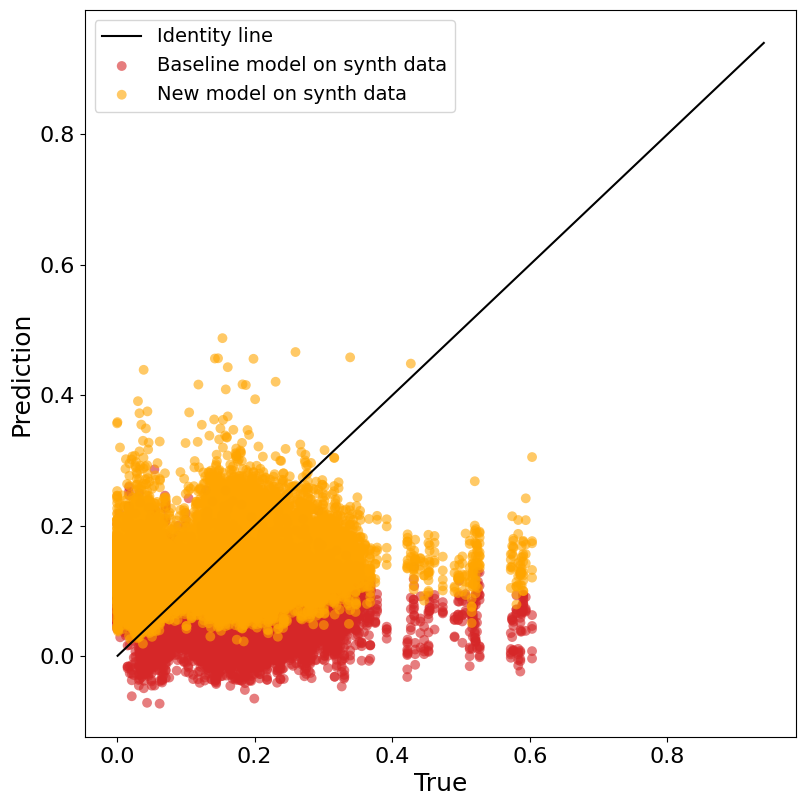

In [33]:
plt.subplots(figsize=(8, 8))

y_tilde = np.load('Checkpoints/data_exp_alpha_1_iter_5.npz')['synth']
synth_pred = np.load('Checkpoints/baseline_pred_exp_alpha_1_iter_5.npz')['synth']
new_model_synth_pred = np.load('Checkpoints/new_model_pred_exp_alpha_1_iter_5.npz')['synth']

# plt.scatter(bad_y.values, xgb.predict(bad_X), alpha=0.6, label='Real bad X', color='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', label='Identity line')
# plt.scatter(augmented_y, baseline_model.predict(augmented_X), alpha=0.6, label='Baseline model on augmented data', color='tab:green', edgecolors='none', s=50)
# plt.scatter(augmented_y, new_model.predict(augmented_X), alpha=0.6, label='New model on augmented data', color='orange', edgecolors='none', s=50)
plt.scatter(y_tilde, synth_pred, alpha=0.6, label='Baseline model on synth data', color='tab:red', edgecolors='none', s=50)
plt.scatter(y_tilde, new_model_synth_pred, alpha=0.6, label='New model on synth data', color='orange', edgecolors='none', s=50)


plt.xlabel('True')
plt.ylabel('Prediction')
plt.legend()
plt.tight_layout(pad=0.5)
# plt.savefig('images/vae_prediction_moscow.pdf', dpi=300)
plt.show()